In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from qiskit_machine_learning.utils import algorithm_globals

import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler, StatevectorEstimator as Estimator
from qiskit_algorithms.optimizers import ADAM
from qiskit_machine_learning.algorithms import VQC
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN, EffectiveDimension, LocalEffectiveDimension, SamplerQNN

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
#loading the datset
iris = load_iris()

X = iris.data       
y = iris.target     


# Task 1

## 1.1

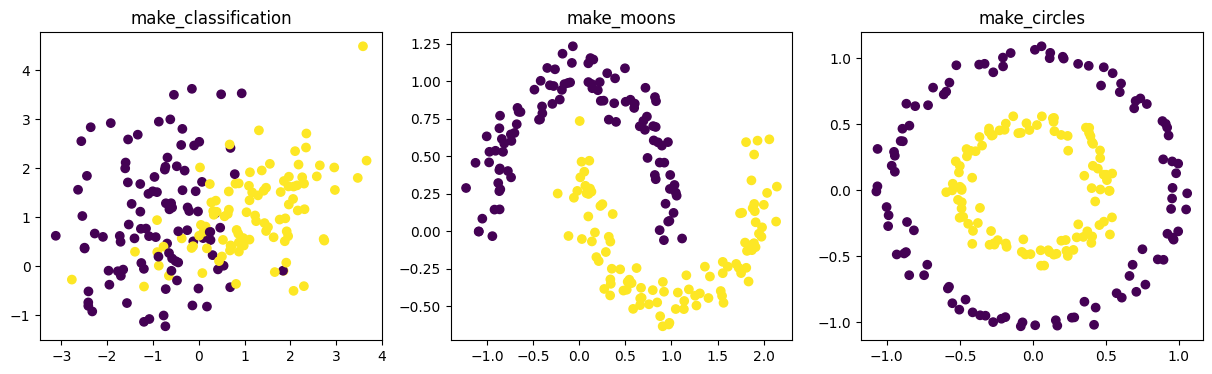

In [57]:
#linear datset
X_class, y_class = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

#moons dataset
X_moons, y_moons = make_moons(
    n_samples=200,
    noise=0.1,
    random_state=42
)

#circles dataset
X_circles, y_circles = make_circles(
    n_samples=200,
    noise=0.05,
    factor=0.5,
    random_state=42
)

#visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_class[:,0], X_class[:,1], c=y_class)
axes[0].set_title("make_classification")

axes[1].scatter(X_moons[:,0], X_moons[:,1], c=y_moons)
axes[1].set_title("make_moons")

axes[2].scatter(X_circles[:,0], X_circles[:,1], c=y_circles)
axes[2].set_title("make_circles")

plt.show()

In [58]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


## 1.2

### setosa vs versicolor

In [59]:
#taking two corresponding labels
mask = y < 2

X_set_vers = X[mask]
y_set_vers = y[mask]

In [60]:
#splitting in training and test
X_train_sv, X_test_sv, y_train_sv, y_test_sv = train_test_split(
    X_set_vers,
    y_set_vers,
    test_size=0.2,
    random_state=42
)

In [61]:
#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_sv = scaler.fit_transform(X_train_sv)
X_test_sv = scaler.transform(X_test_sv)

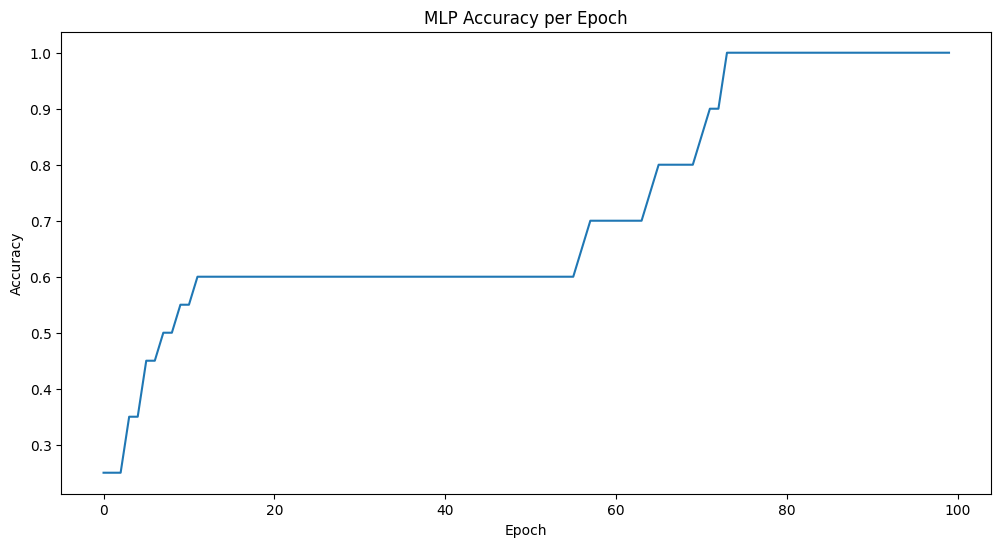

In [62]:
#classical neural network
model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1,   # training step-by-step
    warm_start=True,
    random_state=42
)
epochs = 100
accuracies = []

for i in range(epochs):
    model.fit(X_train_sv, y_train_sv)

    y_pred = model.predict(X_test_sv)
    acc = accuracy_score(y_test_sv, y_pred)

    accuracies.append(acc)
plt.plot(accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy per Epoch")
plt.show()

### versicolor vs virginica

In [63]:
#taking two corresponding labels
mask = y >= 1

X_set_vevi = X[mask]
y_set_vevi = y[mask]

In [64]:
#splitting in training and test
X_train_vevi, X_test_vevi, y_train_vevi, y_test_vevi = train_test_split(
    X_set_vevi,
    y_set_vevi,
    test_size=0.2,
    random_state=42
)

In [65]:
#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_vevi = scaler.fit_transform(X_train_vevi)
X_test_vevi = scaler.transform(X_test_vevi)

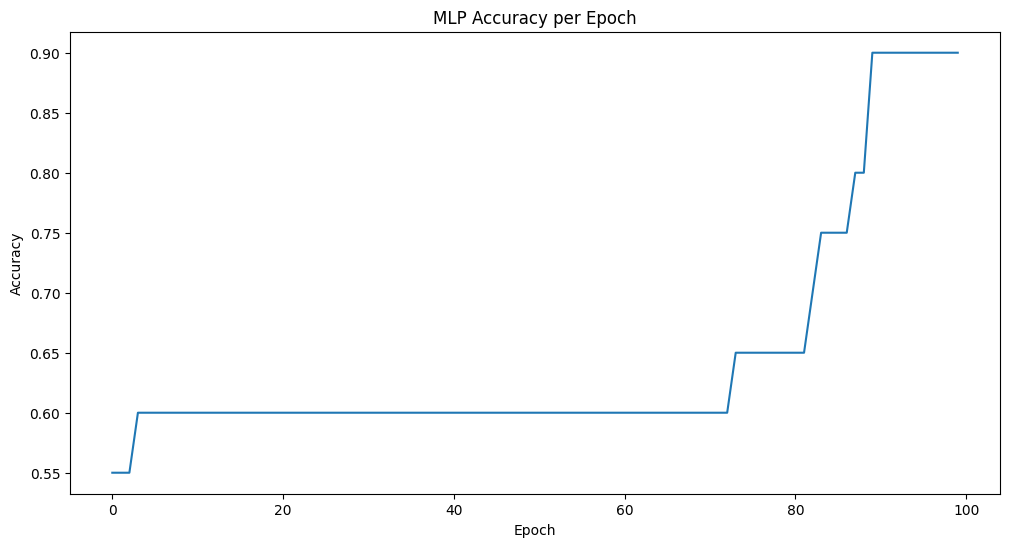

In [66]:
#classical neural network
model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1,   # training step-by-step
    warm_start=True,
    random_state=42
)
epochs = 100
accuracies = []

for i in range(epochs):
    model.fit(X_train_vevi, y_train_vevi)

    y_pred = model.predict(X_test_vevi)
    acc = accuracy_score(y_test_vevi, y_pred)

    accuracies.append(acc)
plt.plot(accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy per Epoch")
plt.show()

### setosa vs virginica

In [67]:
#taking two corresponding labels
mask = y!= 1

X_set_sevi = X[mask]
y_set_sevi = y[mask]

In [68]:
#splitting in training and test
X_train_sevi, X_test_sevi, y_train_sevi, y_test_sevi = train_test_split(
    X_set_sevi,
    y_set_sevi,
    test_size=0.2,
    random_state=42
)

In [69]:
#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_sevi = scaler.fit_transform(X_train_sevi)
X_test_sevi = scaler.transform(X_test_sevi)

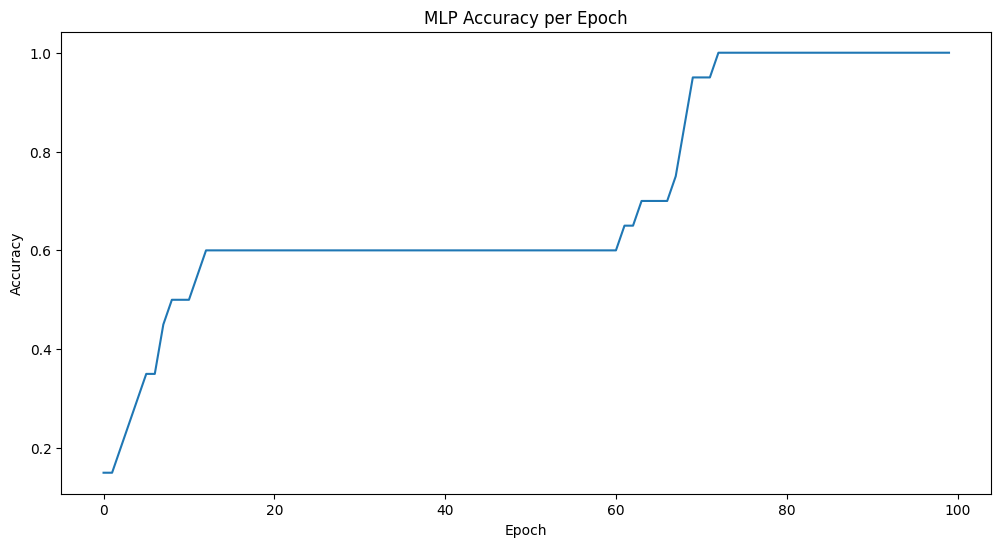

In [70]:
#classical neural network
model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1,   # training step-by-step
    warm_start=True,
    random_state=42
)
epochs = 100
accuracies = []

for i in range(epochs):
    model.fit(X_train_sevi, y_train_sevi)

    y_pred = model.predict(X_test_sevi)
    acc = accuracy_score(y_test_sevi, y_pred)

    accuracies.append(acc)
plt.plot(accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy per Epoch")
plt.show()

### one vs rest 

In [71]:
#Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [72]:
#Scaling the dataset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

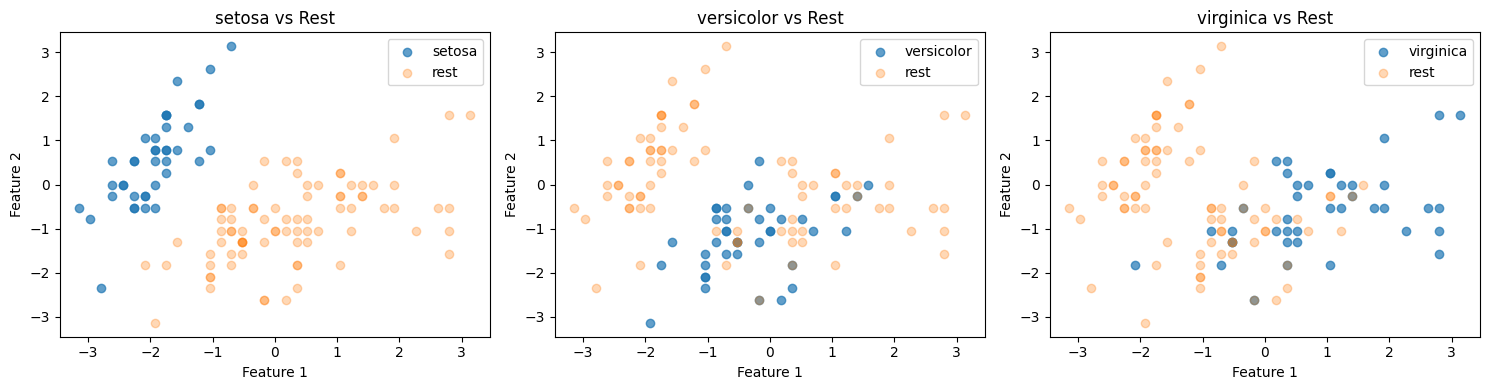

In [73]:
X_vis = X_train[:, :2]

classes = iris.target_names

plt.figure(figsize=(15, 4))

for i, c in enumerate([0, 1, 2]):

    y_bin = (y_train == c)

    plt.subplot(1, 3, i+1)

    plt.scatter(
        X_vis[y_bin, 0],
        X_vis[y_bin, 1],
        label=f"{classes[c]}",
        alpha=0.7
    )

    plt.scatter(
        X_vis[~y_bin, 0],
        X_vis[~y_bin, 1],
        label="rest",
        alpha=0.3
    )

    plt.title(f"{classes[c]} vs Rest")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()

plt.tight_layout()
plt.show()

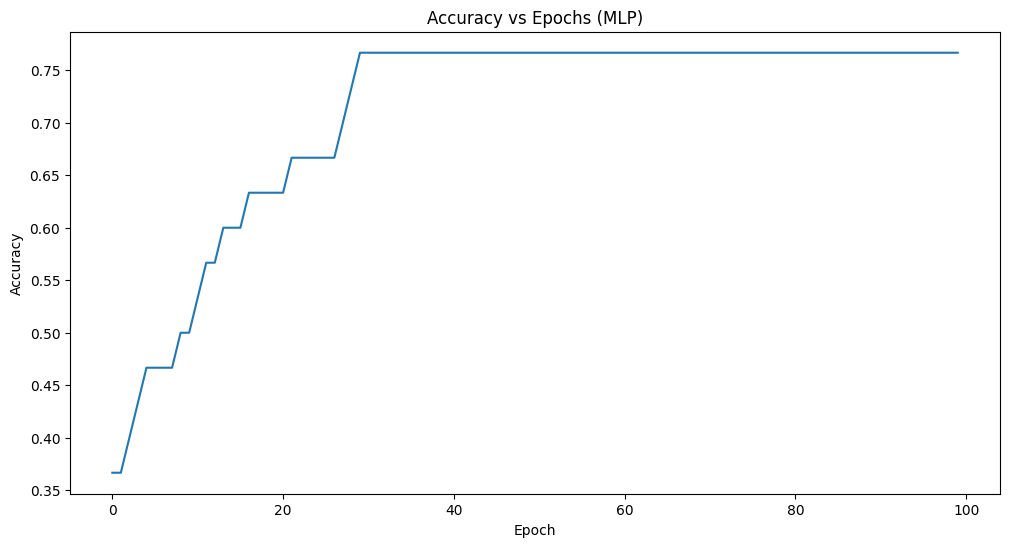

In [74]:
model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1,
    warm_start=True,
    random_state=42
)

epochs = 100
accuracies = []

for epoch in range(epochs):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)

plt.plot(range(epochs), accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs (MLP)")
plt.show()

## 1.4

The dataset is already in 4 dimensions, PCA in 4 dimensions means to just change base 

Having two feautures consents a two qubits quantum network

### e.g setosa vs virgina pca2

In [75]:
#taking two corresponding labels
mask = y!= 1

X_set_sevi = X[mask]
y_set_sevi = y[mask]

In [76]:
#splitting in training and test
X_train_sevi, X_test_sevi, y_train_sevi, y_test_sevi = train_test_split(
    X_set_sevi,
    y_set_sevi,
    test_size=0.2,
    random_state=42
)

In [77]:
#Trasforming the dataset from 4 features to 2 with pca
pca2 = PCA(n_components=2)
X_train_pca2 = pca2.fit_transform(X_train_sevi)
X_test_pca2 = pca2.transform(X_test_sevi)

In [78]:
#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_pca2 = scaler.fit_transform(X_train_pca2)
X_test_pca2 = scaler.transform(X_test_pca2)

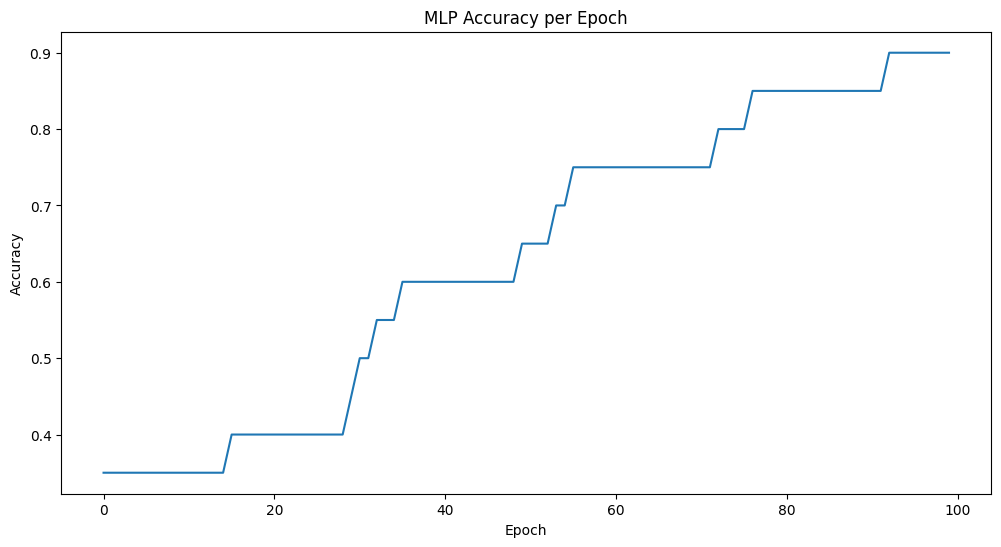

In [79]:
#classical neural network
model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1,   # training step-by-step
    warm_start=True,
    random_state=42
)
epochs = 100
accuracies = []

for i in range(epochs):
    model.fit(X_train_pca2, y_train_sevi)

    y_pred = model.predict(X_test_pca2)
    acc = accuracy_score(y_test_sevi, y_pred)

    accuracies.append(acc)
plt.plot(accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy per Epoch")
plt.show()

# Circuit Components


## Feature Maps

In [7]:
# -----------------------
# Feature Map without entanglement to provide a classical map into a quantum circuit
# -----------------------
def EasyFeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    qc.barrier()
    return qc

# -----------------------
# Feature Map
# -----------------------
def FeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    for i in range(N):
        for j in range(i):
            qc.cx(j, i)
            qc.rz(x[j] * x[i], i)
            qc.cx(j, i)
        qc.barrier()
    return qc




## Ansatz

In [8]:
from qiskit.circuit.library import real_amplitudes
#RealAmplitudes doc. https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RealAmplitudes

from qiskit.circuit.library import efficient_su2 
#EfficentSU2 doc. https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.EfficientSU2

def easy_ansatz(n_bits):
    theta = ParameterVector('theta', n_bits)
    qc = QuantumCircuit(n_bits)
    
    for i in range(n_bits):
        qc.ry(theta[i], i)
        
    return qc


def Ansatz(n_bits):
    theta = ParameterVector('theta', 2*n_bits)
    qc = QuantumCircuit(n_bits)
    for i in range(n_bits):
        qc.ry(theta[i], i)
    qc.barrier()
    for i in range(n_bits-1):
        for j in range(i+1,N):
            qc.cx(i, j)
    qc.barrier()
    for i in range(n_bits):
        qc.ry(theta[i+N], i)
    return qc


## Interpreters


In [9]:
#-----------------------
# Parity Interpreter
# ----------------------
def parity(x):
    return "{:b}".format(x).count("1") % 2


## Builders

In [10]:
def make_sampler_qnn(circ):
    x_p     = sorted([p for p in circ.parameters if p.name.startswith('x')],
                      key=lambda p: p.index)
    theta_p = sorted([p for p in circ.parameters if p.name.startswith('theta')],
                      key=lambda p: p.index)
    return SamplerQNN(
        circuit=circ,
        input_params=x_p,
        weight_params=theta_p,
        interpret=parity,
        output_shape=2,
        sampler=StatevectorSampler(),
    )

def QNN_builder(n_bits, featureMap, ansatz, depth=1):
    fm = featureMap(n_bits)
    a = ansatz(n_bits)
    qc = QuantumCircuit(n_bits)
    for i in range(depth):
        qc = qc.compose(fm.copy())
        qc = qc.compose(a.copy())

    return qc



# Task 2

## 2.1 Creating Quantum Circuit

In [11]:
#taking two corresponding labels
mask = y < 2

X_set = X[mask]
y_set = y[mask]
scaler   = MinMaxScaler(feature_range=(-np.pi, np.pi))        
x_scaled = scaler.fit_transform(X_set)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y_set, test_size=0.2, random_state=42, stratify=y_set
)

N = 4
# Creating the Circuits' parts
easy_feature_map = EasyFeatureMap(N)
feature_map = FeatureMap(N)
ansatz      = Ansatz(N)

### QNN

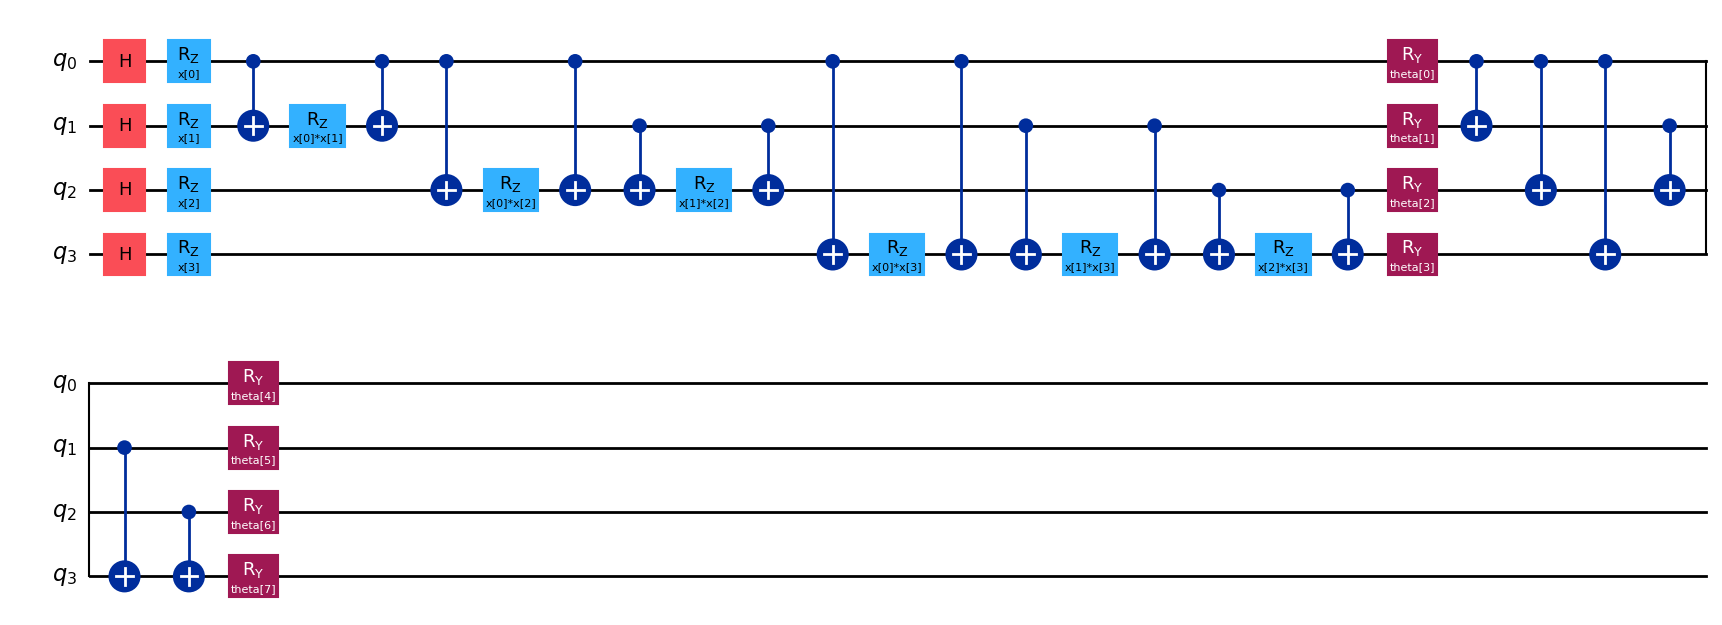

In [26]:
qc = feature_map.copy().compose(ansatz.copy())
qc.draw("mpl", style="iqp", plot_barriers=False)

### easy QNN

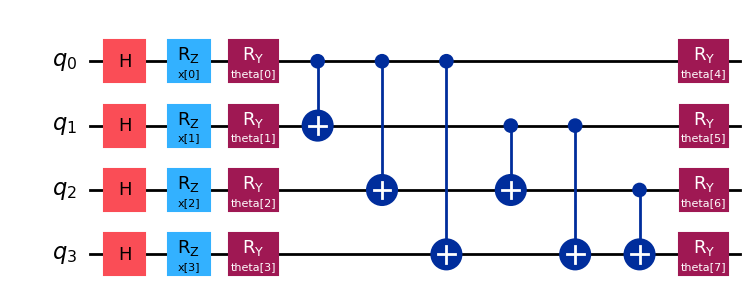

In [27]:
easy_qc = easy_feature_map.copy().compose(ansatz.copy())
easy_qc.draw("mpl", style="iqp", plot_barriers=False)

## 2.2 - SamplerQNN

In [28]:
qnn_s      = make_sampler_qnn(qc)
qnn_s_easy = make_sampler_qnn(easy_qc)

d = qnn_s.num_weights   # number of trainable parameters = 2*N
print(f'num_inputs : {qnn_s.num_inputs}')
print(f'num_weights: {d}')


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


num_inputs : 4
num_weights: 8


## 2.3 - Effective Dimension

In [29]:
'''
algorithm_globals.random_seed = 42

# Dataset sizes to evaluate ED over (as in the official tutorial)
# Needed to see how the QNN can reach complexity
n = [5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]

# ══════════════════════════════════════════════════════════════════════
# 1. GLOBAL EFFECTIVE DIMENSION
# Calcultated over the whole space parameter
# ══════════════════════════════════════════════════════════════════════
global_ed_qnn  = EffectiveDimension(qnn=qnn_s,      weight_samples=50, input_samples=50)
global_ed_easy = EffectiveDimension(qnn=qnn_s_easy, weight_samples=50, input_samples=50)

global_eff_qnn  = global_ed_qnn.get_effective_dimension(dataset_size=n)
global_eff_easy = global_ed_easy.get_effective_dimension(dataset_size=n)

print(f'Global ED QNN  (n=5000): {global_eff_qnn[0]:.4f}  normalized: {global_eff_qnn[0]/d:.4f}')
print(f'Global ED easy (n=5000): {global_eff_easy[0]:.4f}  normalized: {global_eff_easy[0]/d:.4f}')

# ══════════════════════════════════════════════════════════════════════
# 2. LOCAL EFFECTIVE DIMENSION
# calculated around the space parameter found after training the QNN/easy QNN (for trained)
# calculated with random space parameter for not trained QNN/easy QNN
# ══════════════════════════════════════════════════════════════════════

# Random untrained weights (reproducible via algorithm_globals seed)
untrained_weights = algorithm_globals.random.uniform(0, 2 * np.pi, d)

# Trained weights: run a quick VQC fit to get trained parameters
def get_trained_weights(feature_map_fn, ansatz_fn, N, x_tr, y_tr, maxiter=100):
    trained_weights_store = []
    def adam_capture(fun, x0, jac=None, **kwargs):
        opt = ADAM(maxiter=maxiter, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)
        def tracked_jac(w):
            trained_weights_store.append(w.copy())
            return jac(w)
        return opt.minimize(fun=fun, x0=x0, jac=tracked_jac)
    vqc = VQC(
        sampler=StatevectorSampler(),
        feature_map=feature_map_fn(N),
        ansatz=ansatz_fn(N),
        optimizer=adam_capture,
    )
    vqc.fit(x_tr, y_tr)
    return trained_weights_store[-1] if trained_weights_store else vqc.weights

# Training QNNs for local ED
print('Training QNN for local ED...')
trained_weights_qnn  = get_trained_weights(FeatureMap,     Ansatz, N, x_train, y_train)
print('Training easy QNN for local ED...')
trained_weights_easy = get_trained_weights(EasyFeatureMap, Ansatz, N, x_train, y_train)

# Local ED — QNN
local_ed_trained_qnn   = LocalEffectiveDimension(qnn=qnn_s,      weight_samples=trained_weights_qnn,  input_samples=x_train)
local_ed_untrained_qnn = LocalEffectiveDimension(qnn=qnn_s,      weight_samples=untrained_weights,    input_samples=x_train)
# Local ED — easy QNN
local_ed_trained_easy   = LocalEffectiveDimension(qnn=qnn_s_easy, weight_samples=trained_weights_easy, input_samples=x_train)
local_ed_untrained_easy = LocalEffectiveDimension(qnn=qnn_s_easy, weight_samples=untrained_weights,    input_samples=x_train)

local_eff_trained_qnn    = local_ed_trained_qnn.get_effective_dimension(dataset_size=n)
local_eff_untrained_qnn  = local_ed_untrained_qnn.get_effective_dimension(dataset_size=n)
local_eff_trained_easy   = local_ed_trained_easy.get_effective_dimension(dataset_size=n)
local_eff_untrained_easy = local_ed_untrained_easy.get_effective_dimension(dataset_size=n)

# ══════════════════════════════════════════════════════════════════════
# 3. FISHER INFORMATION MATRIX
# ══════════════════════════════════════════════════════════════════════
def compute_fim(ed_obj):
    """Run MC once, return FIM averaged over input samples. Shape: (n_weights, n_weights)"""
    grads, outputs = ed_obj.run_monte_carlo()
    fim = ed_obj.get_fisher_information(grads, outputs)  # (n_samples, n_w, n_w)
    return fim.mean(axis=0)                               # (n_w, n_w)

fim_trained_qnn    = compute_fim(local_ed_trained_qnn)
fim_untrained_qnn  = compute_fim(local_ed_untrained_qnn)
fim_trained_easy   = compute_fim(local_ed_trained_easy)
fim_untrained_easy = compute_fim(local_ed_untrained_easy)

print(f'FIM trace QNN   trained: {np.trace(fim_trained_qnn):.4f}')
print(f'FIM trace QNN untrained: {np.trace(fim_untrained_qnn):.4f}')
print(f'FIM trace easy   trained: {np.trace(fim_trained_easy):.4f}')
print(f'FIM trace easy untrained: {np.trace(fim_untrained_easy):.4f}')
'''

'\nalgorithm_globals.random_seed = 42\n\n# Dataset sizes to evaluate ED over (as in the official tutorial)\n# Needed to see how the QNN can reach complexity\nn = [5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]\n\n# ══════════════════════════════════════════════════════════════════════\n# 1. GLOBAL EFFECTIVE DIMENSION\n# Calcultated over the whole space parameter\n# ══════════════════════════════════════════════════════════════════════\nglobal_ed_qnn  = EffectiveDimension(qnn=qnn_s,      weight_samples=50, input_samples=50)\nglobal_ed_easy = EffectiveDimension(qnn=qnn_s_easy, weight_samples=50, input_samples=50)\n\nglobal_eff_qnn  = global_ed_qnn.get_effective_dimension(dataset_size=n)\nglobal_eff_easy = global_ed_easy.get_effective_dimension(dataset_size=n)\n\nprint(f\'Global ED QNN  (n=5000): {global_eff_qnn[0]:.4f}  normalized: {global_eff_qnn[0]/d:.4f}\')\nprint(f\'Global ED easy (n=5000): {global_eff_easy[0]:.4f}  normalized: {global_eff_easy[0]/d:.4f}\')

In [30]:
'''
# Effective Dimension
with open("DATA/global_eff_qnn.pkl", "wb") as f:
    pickle.dump(global_eff_qnn, f)
with open("DATA/global_eff_easy.pkl", "wb") as f:
    pickle.dump(global_eff_easy, f)
with open("DATA/local_eff_trained_qnn.pkl", "wb") as f:
    pickle.dump(local_eff_trained_qnn, f)
with open("DATA/local_eff_trained_easy.pkl", "wb") as f:
    pickle.dump(local_eff_trained_easy, f)
with open("DATA/local_eff_untrained_qnn.pkl", "wb") as f:
    pickle.dump(local_eff_untrained_qnn, f)
with open("DATA/local_eff_untrained_easy.pkl", "wb") as f:
    pickle.dump(local_eff_untrained_easy, f)

# Fisher Information
with open("DATA/fim_trained_qnn.pkl", "wb") as f:
    pickle.dump(fim_trained_qnn, f)
with open("DATA/fim_trained_easy.pkl", "wb") as f:
    pickle.dump(fim_trained_easy, f)
with open("DATA/fim_untrained_qnn.pkl", "wb") as f:
    pickle.dump(fim_untrained_qnn, f)
with open("DATA/fim_untrained_easy.pkl", "wb") as f:
    pickle.dump(fim_untrained_easy, f)
'''

'\n# Effective Dimension\nwith open("DATA/global_eff_qnn.pkl", "wb") as f:\n    pickle.dump(global_eff_qnn, f)\nwith open("DATA/global_eff_easy.pkl", "wb") as f:\n    pickle.dump(global_eff_easy, f)\nwith open("DATA/local_eff_trained_qnn.pkl", "wb") as f:\n    pickle.dump(local_eff_trained_qnn, f)\nwith open("DATA/local_eff_trained_easy.pkl", "wb") as f:\n    pickle.dump(local_eff_trained_easy, f)\nwith open("DATA/local_eff_untrained_qnn.pkl", "wb") as f:\n    pickle.dump(local_eff_untrained_qnn, f)\nwith open("DATA/local_eff_untrained_easy.pkl", "wb") as f:\n    pickle.dump(local_eff_untrained_easy, f)\n\n# Fisher Information\nwith open("DATA/fim_trained_qnn.pkl", "wb") as f:\n    pickle.dump(fim_trained_qnn, f)\nwith open("DATA/fim_trained_easy.pkl", "wb") as f:\n    pickle.dump(fim_trained_easy, f)\nwith open("DATA/fim_untrained_qnn.pkl", "wb") as f:\n    pickle.dump(fim_untrained_qnn, f)\nwith open("DATA/fim_untrained_easy.pkl", "wb") as f:\n    pickle.dump(fim_untrained_easy, f)\n

RESULTS OF QNN and EASY QNN:
---------------------------------------
Global ED QNN  		(n=5000): 7.0586  normalized: 0.8823
Global ED easy 		(n=5000): 5.7568  normalized: 0.7196
Local trained ED QNN  	(n=5000): 7.5252  normalized: 0.9406
Local trained ED easy 	(n=5000): 6.1394  normalized: 0.7674
--------------------------------------
FIM trace QNN   trained:	 0.3869
FIM trace QNN untrained:	 0.3457
FIM trace easy   trained:	 0.3338
FIM trace easy untrained:	 0.2976


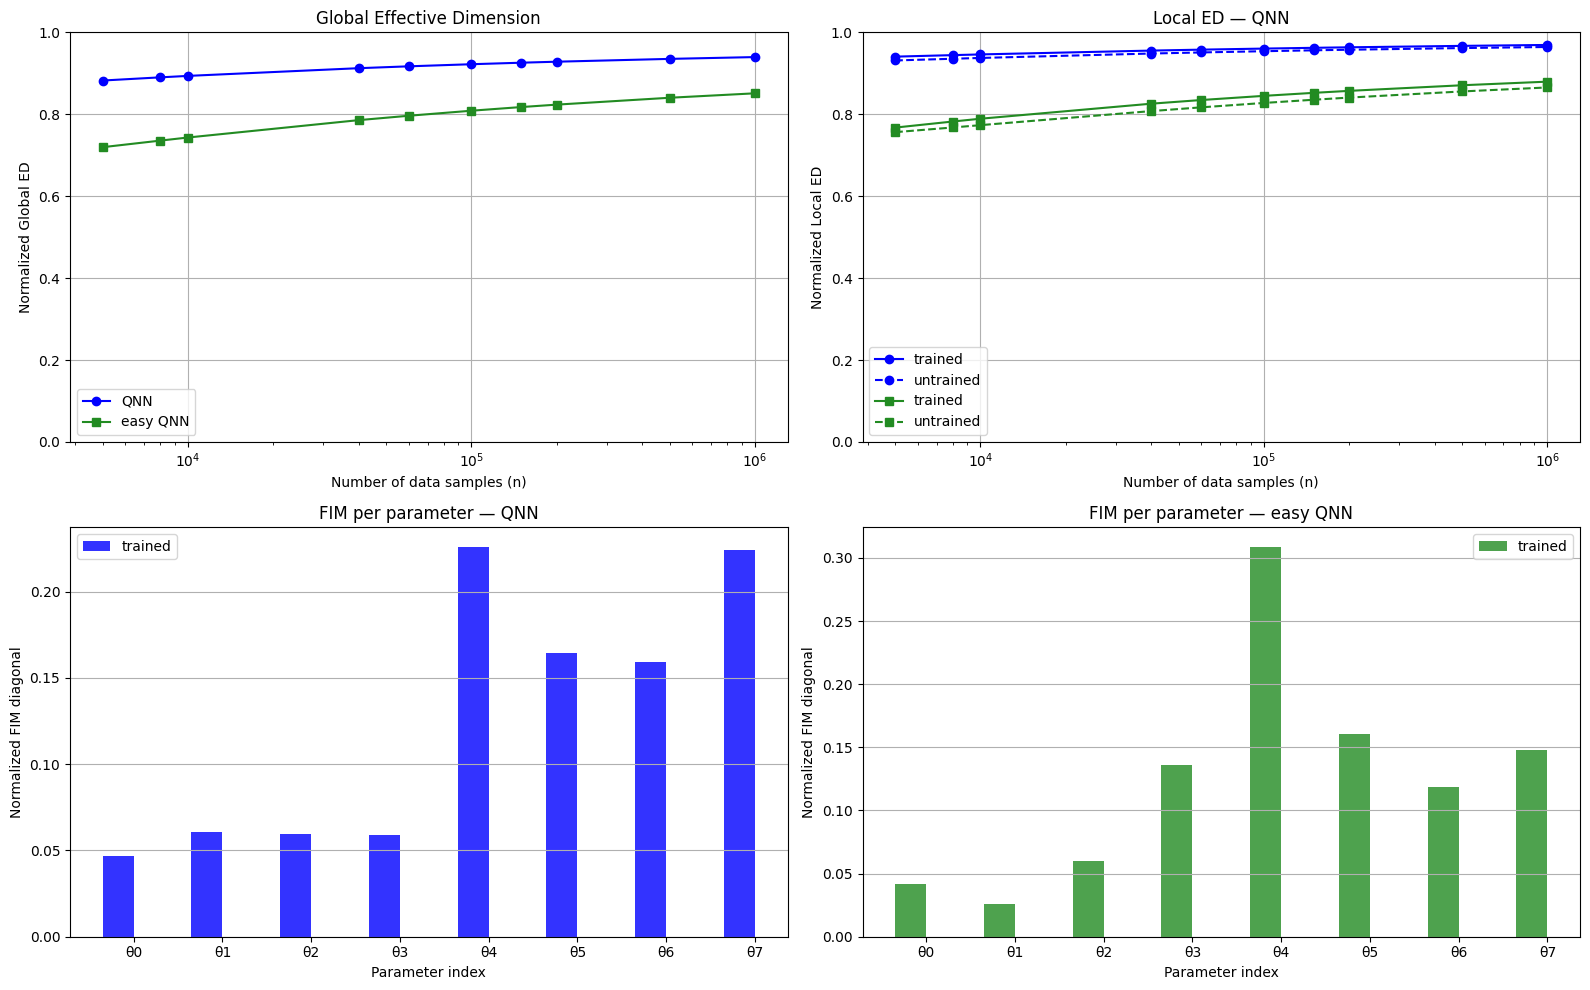

In [31]:
n = [5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]
global_eff_qnn = np.load('DATA/global_eff_qnn.pkl', allow_pickle=True)
global_eff_easy = np.load('DATA/global_eff_easy.pkl', allow_pickle=True)
local_eff_trained_qnn = np.load('DATA/local_eff_trained_qnn.pkl', allow_pickle=True)
local_eff_trained_easy = np.load('DATA/local_eff_trained_easy.pkl', allow_pickle=True)
local_eff_untrained_qnn = np.load('DATA/local_eff_untrained_qnn.pkl', allow_pickle=True)
local_eff_untrained_easy = np.load('DATA/local_eff_untrained_easy.pkl', allow_pickle=True)
fim_trained_qnn = np.load('DATA/fim_trained_qnn.pkl', allow_pickle=True)
fim_trained_easy = np.load('DATA/fim_trained_easy.pkl', allow_pickle=True)
fim_untrained_qnn = np.load('DATA/fim_untrained_qnn.pkl', allow_pickle=True)
fim_untrained_easy = np.load('DATA/fim_untrained_easy.pkl', allow_pickle=True)
# RESULTS
print(f'RESULTS OF QNN and EASY QNN:')
print(f'---------------------------------------')
print(f'Global ED QNN  \t\t(n=5000): {global_eff_qnn[0]:.4f}  normalized: {global_eff_qnn[0]/d:.4f}')
print(f'Global ED easy \t\t(n=5000): {global_eff_easy[0]:.4f}  normalized: {global_eff_easy[0]/d:.4f}')
print(f'Local trained ED QNN  \t(n=5000): {local_eff_trained_qnn[0]:.4f}  normalized: {local_eff_trained_qnn[0]/d:.4f}')
print(f'Local trained ED easy \t(n=5000): {local_eff_trained_easy[0]:.4f}  normalized: {local_eff_trained_easy[0]/d:.4f}')
print(f'--------------------------------------')

print(f'FIM trace QNN   trained:\t {np.trace(fim_trained_qnn):.4f}')
print(f'FIM trace QNN untrained:\t {np.trace(fim_untrained_qnn):.4f}')
print(f'FIM trace easy   trained:\t {np.trace(fim_trained_easy):.4f}')
print(f'FIM trace easy untrained:\t {np.trace(fim_untrained_easy):.4f}')


# ══════════════════════════════════════════════════════════════════════
# 4. PLOTS
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Row 1: Effective Dimension ────────────────────────────────
# Global ED
axes[0,0].plot(n, np.array(global_eff_qnn)  / d, marker='o', color='blue',        label='QNN')
axes[0,0].plot(n, np.array(global_eff_easy) / d, marker='s', color='forestgreen', label='easy QNN')
axes[0,0].set_xscale('log')
axes[0,0].set_ylim([0, 1])
axes[0,0].set_xlabel('Number of data samples (n)')
axes[0,0].set_ylabel('Normalized Global ED')
axes[0,0].set_title('Global Effective Dimension')
axes[0,0].legend()
axes[0,0].grid(True)

# Local ED — QNN
axes[0,1].plot(n, np.array(local_eff_trained_qnn)   / d, color='blue', marker='o', label='trained')
axes[0,1].plot(n, np.array(local_eff_untrained_qnn) / d, color='blue', marker='o', label='untrained', linestyle='--')
axes[0,1].plot(n, np.array(local_eff_trained_easy)   / d, color='forestgreen', marker='s', label='trained')
axes[0,1].plot(n, np.array(local_eff_untrained_easy) / d, color='forestgreen', marker='s', label='untrained', linestyle='--')

axes[0,1].set_xscale('log')
axes[0,1].set_ylim([0, 1])
axes[0,1].set_xlabel('Number of data samples (n)')
axes[0,1].set_ylabel('Normalized Local ED')
axes[0,1].set_title('Local ED — QNN')
axes[0,1].legend()
axes[0,1].grid(True)

# Local ED — easy QNN


# ── Row 2: Fisher Information ─────────────────────────────────
# Autovalori normalizzati per parametro (diagonale della FIM normalizzata)
diag_trained_qnn    = np.diag(fim_trained_qnn)    / np.sum(np.diag(fim_trained_qnn))
diag_untrained_qnn  = np.diag(fim_untrained_qnn)  / np.sum(np.diag(fim_untrained_qnn))
diag_trained_easy   = np.diag(fim_trained_easy)   / np.sum(np.diag(fim_trained_easy))
diag_untrained_easy = np.diag(fim_untrained_easy) / np.sum(np.diag(fim_untrained_easy))

x_idx = np.arange(d)
width = 0.35

# ── QNN ───────────────────────────────────────────────────────
axes[1,0].bar(x_idx - width/2, diag_trained_qnn,   width, label='trained',   color='blue',  alpha=0.8)
#axes[1,0].bar(x_idx + width/2, diag_untrained_qnn, width, label='untrained', color='blue',  alpha=0.3)
axes[1,0].set_xticks(x_idx)
axes[1,0].set_xticklabels([f'θ{i}' for i in range(d)])
axes[1,0].set_xlabel('Parameter index')
axes[1,0].set_ylabel('Normalized FIM diagonal')
axes[1,0].set_title('FIM per parameter — QNN')
axes[1,0].legend()
axes[1,0].grid(True, axis='y')

# ── easy QNN ──────────────────────────────────────────────────
axes[1,1].bar(x_idx - width/2, diag_trained_easy,   width, label='trained',   color='forestgreen', alpha=0.8)
#axes[1,1].bar(x_idx + width/2, diag_untrained_easy, width, label='untrained', color='forestgreen', alpha=0.3)
axes[1,1].set_xticks(x_idx)
axes[1,1].set_xticklabels([f'θ{i}' for i in range(d)])
axes[1,1].set_xlabel('Parameter index')
axes[1,1].set_ylabel('Normalized FIM diagonal')
axes[1,1].set_title('FIM per parameter — easy QNN')
axes[1,1].legend()
axes[1,1].grid(True, axis='y')
"""
# FIM heatmap — QNN trained
im0 = axes[1,0].imshow(fim_trained_qnn, cmap='viridis')
axes[1,0].set_title('FIM — QNN trained')
axes[1,0].set_xlabel('Parameter index')
axes[1,0].set_ylabel('Parameter index')
plt.colorbar(im0, ax=axes[1,0])

# FIM heatmap — easy QNN trained
im1 = axes[1,1].imshow(fim_trained_easy, cmap='viridis')
axes[1,1].set_title('FIM — easy QNN trained')
axes[1,1].set_xlabel('Parameter index')
axes[1,1].set_ylabel('Parameter index')
plt.colorbar(im1, ax=axes[1,1])

# Eigenvalue spectrum: trained vs untrained for both models
eig_trained_qnn    = np.sort(np.linalg.eigvalsh(fim_trained_qnn))[::-1]
eig_untrained_qnn  = np.sort(np.linalg.eigvalsh(fim_untrained_qnn))[::-1]
eig_trained_easy   = np.sort(np.linalg.eigvalsh(fim_trained_easy))[::-1]
eig_untrained_easy = np.sort(np.linalg.eigvalsh(fim_untrained_easy))[::-1]

x_idx = range(1, d + 1)
axes[1,2].semilogy(x_idx, eig_trained_qnn,    'o-',  color='blue',        label='QNN trained')
axes[1,2].semilogy(x_idx, eig_untrained_qnn,  'o--', color='blue',        label='QNN untrained', alpha=0.5)
axes[1,2].semilogy(x_idx, eig_trained_easy,   's-',  color='forestgreen', label='easy trained')
axes[1,2].semilogy(x_idx, eig_untrained_easy, 's--', color='forestgreen', label='easy untrained', alpha=0.5)
axes[1,2].set_xlabel('Eigenvalue index')
axes[1,2].set_ylabel('Eigenvalue (log scale)')
axes[1,2].set_title('FIM Eigenvalue Spectrum')
axes[1,2].legend(fontsize=8)
axes[1,2].grid(True)
"""
plt.tight_layout()
plt.show()

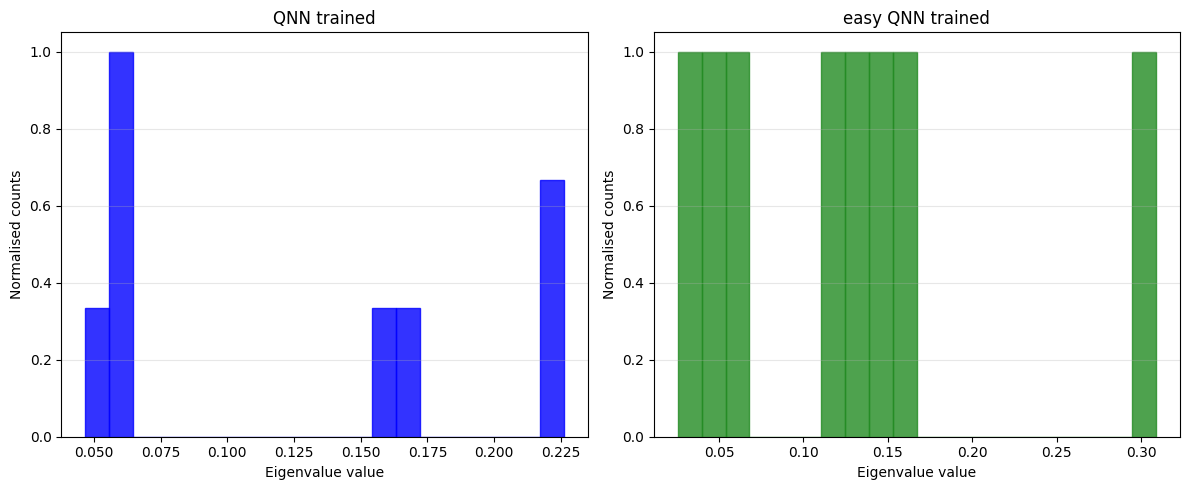

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models_to_plot = [
    ('QNN trained',        'blue', diag_trained_qnn),
    ('easy QNN trained',   'forestgreen',diag_trained_easy),
]

for ax, (name, color,eigenvalues) in zip(axes, models_to_plot):

    counts, bin_edges = np.histogram(eigenvalues, bins=20)
    counts_norm = counts / counts.max()   

    ax.bar(bin_edges[:-1], counts_norm,
           width=np.diff(bin_edges),
           color=color, edgecolor=color,
           alpha=0.8, align='edge')

    ax.set_xlabel('Eigenvalue value')
    ax.set_ylabel('Normalised counts')
    ax.set_ylim([0, 1.05])
    ax.set_title(name)
    #ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Task 3

Task 3 - Implement quantum neural-network architectures
* Implement a modular QNN constructor in Qiskit. The constructor should accept number of qubits, feature
map type, ansatz type, ansatz depth, and output interpretation.
* Easy quantum model: ZFeatureMap plus RealAmplitudes, shallow feature-map depth.
* QNN: ZZFeatureMap or another entangling feature map plus RealAmplitudes or EfficientSU2.
* Test at least 2-qubit and 4-qubit models.
* For each architecture, report number of trainable parameters, number of input parameters, circuit depth,
and two-qubit gate count.
* Implement model outputs using SamplerQNN or EstimatorQNN. Use SamplerQNN for parity-style
classification and EstimatorQNN for expectation-value outputs if useful.

In [92]:
n_bits = [2, 4]
featureMap = [EasyFeatureMap, FeatureMap]
ansatz = [easy_ansatz, Ansatz, real_amplitudes, efficient_su2]
depth = [1, 5, 10]
quantumCircuits = {}
samplers = {}
estimators = {}
for n in n_bits:
    for fm in featureMap:
        for a in ansatz:
            for d in depth:
                quantumCircuits[(n, fm, a, d)] = QNN_builder(n, fm, a, depth=d)
                #samplers[(n, fm, a, d)] = make_sampler_qnn(quantumCircuits[(n, fm, a, d)])

CircuitError: 'Index 2 out of range for size 2.'

In [93]:
print(circ.parameters)

NameError: name 'circ' is not defined

In [94]:


for n in n_bits:
    for fm in featureMap:
        for a in ansatz:
            for d in depth:
                circ = quantumCircuits[(n, fm, a, d)]
                x_p = sorted([p for p in circ.parameters if p.name.startswith('x')], key=lambda p: p.name)
                theta_p = sorted([p for p in circ.parameters if p.name.startswith('theta') or p.name.startswith('θ')], key=lambda p: p.name)            
                samplers[(n, fm, a, d)] = SamplerQNN(circuit=circ,
                                                     input_params=x_p,
                                                     weight_params=theta_p,
                                                     interpret=parity,
                                                     output_shape=2,
                                                     sampler=StatevectorSampler()) 


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


KeyError: (2, <function EasyFeatureMap at 0x7162ef1a6a20>, <function Ansatz at 0x7162ef1a6b60>, 1)

In [95]:
for n in n_bits:
    for fm in featureMap:
        for a in ansatz:
            for d in depth:
                samp = samplers[(n, fm, a, d)]
                circ = quantumCircuits[(n, fm, a, d)]

                w = samp.num_weights
                i = samp.num_inputs
                tqc = circ.num_nonlocal_gates()
                
                fm_name = fm.__name__
                ansatz_name = a.__name__
                print("--------------------------------------------------------------------------")
                print(f"Qubits: {n} | FeatureMap: {fm_name} | Ansatz: {ansatz_name} | Depth: {d}")
                print(f"Inputs number: {i}")
                print(f"Weights number: {w}")
                print(f"Two-Qubit Gate number: {tqc}")


--------------------------------------------------------------------------
Qubits: 2 | FeatureMap: EasyFeatureMap | Ansatz: easy_ansatz | Depth: 1
Inputs number: 2
Weights number: 2
Two-Qubit Gate number: 0
--------------------------------------------------------------------------
Qubits: 2 | FeatureMap: EasyFeatureMap | Ansatz: easy_ansatz | Depth: 5
Inputs number: 2
Weights number: 2
Two-Qubit Gate number: 0
--------------------------------------------------------------------------
Qubits: 2 | FeatureMap: EasyFeatureMap | Ansatz: easy_ansatz | Depth: 10
Inputs number: 2
Weights number: 2
Two-Qubit Gate number: 0


KeyError: (2, <function EasyFeatureMap at 0x7162ef1a6a20>, <function Ansatz at 0x7162ef1a6b60>, 1)

### classical NN

In [96]:
def build_model(input_lenght=4, depth=5, n_class=2):
    model = Sequential()
    
    # Primo strato (ha bisogno dell'input_shape implicito o esplicito)
    model.add(Dense(input_lenght, kernel_initializer='he_normal', input_shape=(input_lenght,)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1)) # 'alpha' nelle vecchie versioni di Keras
    
    # I restanti strati nascosti (depth - 1)
    for _ in range(depth - 1):
        model.add(Dense(input_lenght, kernel_initializer='he_normal'))
        model.add(BatchNormalization())
        model.add(LeakyReLU(negative_slope=0.1))
        
    # Strato di Output (Sempre con Softmax per la classificazione!)
    model.add(Dense(n_class, activation='softmax', kernel_initializer='he_normal'))
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [97]:
mask = y < 2

X_set_vers = X[mask]
y_set_vers = y[mask]
X_train_sv, X_test_sv, y_train_sv, y_test_sv = train_test_split(
    X_set_vers,
    y_set_vers,
    test_size=0.2,
    random_state=42
)

In [98]:
EPOCHS = 100
BATCH_SIZE = 32
Loss1 = []
Accuracy1 = []
for _ in range(40):
    model = build_model(depth=5, n_class=2)
    fit = model.fit(X_train_sv, y_train_sv,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(X_test_sv, y_test_sv),
                    verbose=False,
                    shuffle=True)    
    loss1 = np.array(fit.history['loss'])
    accuracy1 = np.array(fit.history['accuracy'])
    Loss1.append(loss1)
    Accuracy1.append(accuracy1)

Loss1 = np.array(Loss1)         
Accuracy1 = np.array(Accuracy1) 

loss_mean1 = np.mean(Loss1, axis=0)
loss_std1 = np.std(Loss1, axis=0)

acc_mean1 = np.mean(Accuracy1, axis=0)
acc_std1 = np.std(Accuracy1, axis=0)

NameError: name 'Sequential' is not defined

In [99]:
epochs = np.arange(EPOCHS)

plt.plot(epochs, loss_mean1, label="Loss mean")
plt.fill_between(
    epochs,
    loss_mean1 - loss_std1,
    loss_mean1 + loss_std1,
    alpha=0.3
)

plt.plot(epochs, acc_mean1, label="Accuracy mean")
plt.fill_between(
    epochs,
    acc_mean1 - acc_std1,
    acc_mean1 + acc_std1,
    alpha=0.3
)

plt.legend()
plt.show()

NameError: name 'loss_mean1' is not defined

In [100]:
def compute_fisher(model, X, y):

    fisher = np.zeros((4, 4))

    dataset = tf.data.Dataset.from_tensor_slices((X, y)).batch(1)

    for x_batch, y_batch in dataset:

        x_batch = tf.cast(x_batch, tf.float32)

        with tf.GradientTape() as tape:
            tape.watch(x_batch)   

            preds = model(x_batch, training=False)

            loss = tf.keras.losses.sparse_categorical_crossentropy(
                y_batch,
                preds
            )

        grads = tape.gradient(loss, x_batch)

        if grads is None:
            continue  # safety check

        g = tf.reshape(grads, (4,)).numpy()

        fisher += np.outer(g, g)

    fisher /= len(X)

    return fisher

In [101]:
F = compute_fisher(model, X_train_sv, y_train_sv)
F

NameError: name 'tf' is not defined

In [102]:
def effective_dimension(F, n):

    d = F.shape[0]

    kappa = n / (2 * np.pi * np.log(n))

    #normalization
    F_hat = d * F / np.trace(F)

    I = np.eye(d)

    M = I + kappa * F_hat

    sign, logdet = np.linalg.slogdet(M)

    d_eff = logdet / np.log(kappa)

    return d_eff
effective_dimension(F,300)/F.shape[0]

NameError: name 'F' is not defined

In [103]:
t = F.trace()

eigvals, eigvecs = np.linalg.eigh(F)

for i in range(len(eigvals)):
    M = np.sort(eigvals)[::-1][i]
    M/t
    print(f'Information in eigenvalue {i}: {M/t:.2f}')
    
plt.bar(np.arange(len(eigvals)), eigvals, width=0.5, color='steelblue')

plt.xlabel("Index (sorted)")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalue Spectrum (Bar Plot)")
plt.yscale("log")
plt.xticks(np.arange(0, len(eigvals), 1))
plt.yticks([1e-4, 1e-3, 1e-2, 1e-1])
plt.grid()
plt.show()

NameError: name 'F' is not defined

## PCA

In [104]:
U, S, VT = np.linalg.svd(F)

idx = np.argsort(eigvals)[::-1]

U = U[:, idx]

U2 = U[:, :2]

X_train_fisher2 = X_train_sv @ U2
X_test_fisher2 = X_test_sv @ U2

NameError: name 'F' is not defined

In [105]:
def build_model2(input_lenght=2, depth=5, n_class=2):
    model = Sequential()
    
    # Primo strato (ha bisogno dell'input_shape implicito o esplicito)
    model.add(Dense(input_lenght, kernel_initializer='he_normal', input_shape=(input_lenght,)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1)) # 'alpha' nelle vecchie versioni di Keras
    
    # I restanti strati nascosti (depth - 1)
    for _ in range(depth - 1):
        model.add(Dense(input_lenght, kernel_initializer='he_normal'))
        model.add(BatchNormalization())
        model.add(LeakyReLU(negative_slope=0.1))
        
    # Strato di Output (Sempre con Softmax per la classificazione!)
    model.add(Dense(n_class, activation='softmax', kernel_initializer='he_normal'))
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [106]:
EPOCHS = 100
BATCH_SIZE = 32
Loss2 = []
Accuracy2 = []
for _ in range(40):
    model = build_model2(depth=5, n_class=2)
    fit = model.fit(X_train_fisher2, y_train_sv,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(X_test_fisher2, y_test_sv),
                    verbose=False,
                    shuffle=True)        
    loss = np.array(fit.history['loss'])
    accuracy  = np.array(fit.history['accuracy'])
    Loss2.append(loss)
    Accuracy2.append(accuracy)

    
Loss2 = np.array(Loss2)         
Accuracy2 = np.array(Accuracy2) 

loss_mean2 = np.mean(Loss2, axis=0)
loss_std2 = np.std(Loss2, axis=0)

acc_mean2 = np.mean(Accuracy2, axis=0)
acc_std2 = np.std(Accuracy2, axis=0)

NameError: name 'Sequential' is not defined

In [107]:
epochs = np.arange(EPOCHS)

plt.plot(epochs, loss_mean2, label="Loss mean")
plt.fill_between(
    epochs,
    loss_mean2 - loss_std2,
    loss_mean2 + loss_std2,
    alpha=0.3
)

plt.plot(epochs, acc_mean2, label="Accuracy mean")
plt.fill_between(
    epochs,
    acc_mean2 - acc_std2,
    acc_mean2 + acc_std2,
    alpha=0.3
)

plt.legend()
plt.show()

NameError: name 'loss_mean2' is not defined

In [108]:
epochs = np.arange(EPOCHS)

plt.plot(epochs, loss_mean1, label="Loss mean 4 parameters")
plt.fill_between(
    epochs,
    loss_mean1 - loss_std1,
    loss_mean1 + loss_std1,
    alpha=0.3
)

plt.plot(epochs, loss_mean2, label="Loss mean 2 parameters")
plt.fill_between(
    epochs,
    loss_mean2 - loss_std2,
    loss_mean2 + loss_std2,
    alpha=0.3
)
plt.legend()
plt.show()

NameError: name 'loss_mean1' is not defined

In [109]:
plt.plot(epochs, acc_mean1, label="Accuracy mean 4 parameters")
plt.fill_between(
    epochs,
    acc_mean1 - acc_std1,
    acc_mean1 + acc_std1,
    alpha=0.3
)
plt.plot(epochs, acc_mean2, label="Accuracy mean 2 parameters")
plt.fill_between(
    epochs,
    acc_mean2 - acc_std2,
    acc_mean2 + acc_std2,
    alpha=0.3
)

plt.legend()
plt.show()

NameError: name 'acc_mean1' is not defined

# Task 4

* Implement classical feedforward neural networks using or other libraries (PyTorch or scikit-learn).
* Use architectures with trainable-parameter counts comparable to the QNNs whenever possible.
* Report train accuracy, test accuracy, loss curves, number of parameters, and runtime.

In [110]:
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input


I0000 00:00:1780060071.418022 1751681 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780060071.452491 1751681 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780060072.668859 1751681 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [111]:
def build_model(input_lenght=4, depth=5, n_class=2):

    input_shape = (input_lenght, 1)
    
    reg = tf.keras.regularizers.l2(0)
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, seed=None)
    
    model = Sequential([ Dense(input_lenght, activation='relu') for d in range(depth)], Dense(n_class, activation='softmax'))
    
   
    model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', # Fixed here
              metrics=['accuracy'])
    
    return model
    

In [112]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, LeakyReLU

def build_model(input_lenght=4, depth=5, n_class=2):
    model = Sequential()
    
    # Primo strato (ha bisogno dell'input_shape implicito o esplicito)
    model.add(Dense(input_lenght, kernel_initializer='he_normal', input_shape=(input_lenght,)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1)) # 'alpha' nelle vecchie versioni di Keras
    
    # I restanti strati nascosti (depth - 1)
    for _ in range(depth - 1):
        model.add(Dense(input_lenght, kernel_initializer='he_normal'))
        model.add(BatchNormalization())
        model.add(LeakyReLU(negative_slope=0.1))
        
    # Strato di Output (Sempre con Softmax per la classificazione!)
    model.add(Dense(n_class, activation='softmax', kernel_initializer='he_normal'))
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [113]:

EPOCHS = 100
BATCH_SIZE = 10

accuracy = []
for _ in range(40):
    model = build_model(depth=5, n_class=3)
    fit = model.fit(X_train, y_train,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(X_test, y_test),
                    verbose=False,
                    shuffle=True)
    
    accuracy.append(fit.history['val_accuracy'])

accuracy = np.array(accuracy)

/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1780060072.870636 1751681 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 120
'y' sizes: 80


In [ ]:
mean = np.mean(accuracy, axis=0)
std  = np.std(accuracy, axis=0)

plt.fill_between(range(100),mean-std, mean+std, alpha=0.5)
plt.plot(range(100),mean)


In [ ]:
import pickle

with open("accuracy_classical_fnn.pkl", "wb") as f:
    pickle.dump(accuracy, f)

# Task 5

ciao, hello

# Task 6

# Task 7 - Train the models and compute local effective dimension

• Train selected QNNs and classical baselines on one synthetic dataset and the Iris binary tasks. \
• Use several random initializations, for example 5 seeds for the reduced project and 20 seeds if runtime
permits. \
• For QNNs, use COBYLA, SPSA, SLSQP, or another optimizer supported by Qiskit Machine Learning. \
• Plot training loss and test accuracy versus iteration; reproduce Figure on: Training loss and test accuracy
After training, compute local effective d 

We choose X_moons, y_moons as synthetic dataset and (X_train_sv, X_test_sv, y_train_sv, y_test_sv) setosa-virginica as Iris binary task

In [3]:
'''
That's the code for the CL NN, but it needs to be changed
'''

def build_model2(input_lenght=4, depth=2, n_class=2):

    model = Sequential()

    model.add(Dense(
        4,
        input_shape=(input_lenght,),
        activation='relu'
    ))

    for _ in range(depth - 1):

        model.add(Dense(
            4,
            activation='relu',
            use_bias=False
        ))

    model.add(Dense(
        n_class,
        activation='softmax',
        use_bias=False
    ))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_model2(depth=3, n_class=2)

params = model.trainable_variables

# numero totale parametri
d = np.sum([tf.size(p).numpy() for p in params])
print(d)


NameError: name 'Sequential' is not defined

In [115]:
from numpy import random
# iterate over different seeds
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
algorithm_globals.random_seed = SEED

In [116]:
# datasets
# changing it because it requires 4 inputs
X_class, y_class = make_classification(
    n_samples=200,
    n_features=4,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

# synthetic dataset
X_s = X_class
y_s = y_class
X_s_tr, X_s_test, y_s_tr, y_s_test = train_test_split(
    X_s,
    y_s,
    test_size=0.4,
    random_state=SEED
)

scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_s_tr = scaler.fit_transform(X_s_tr)
X_s_test = scaler.transform(X_s_test)

# binary dataset - setosa vs virginica
# already splitted and scaled above
X_b_tr = X_train_sv
X_b_test = X_test_sv
y_b_tr = y_train_sv
y_b_test = y_test_sv

In [148]:
# defining models
CL_model = build_model2(input_lenght=4, depth=5, n_class=2) # TO CHANGE

In [149]:
# training classical model
EPOCHS = 100
BATCH_SIZE = 10

CL_fit_synth = CL_model.fit(X_s_tr, y_s_tr,
                batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(X_s_test, y_s_test),
                verbose=False,
                shuffle=True)

CL_trloss_synth = np.array(CL_fit_synth.history['loss'])

CL_val_acc_synth = np.array(CL_fit_synth.history['val_accuracy'])

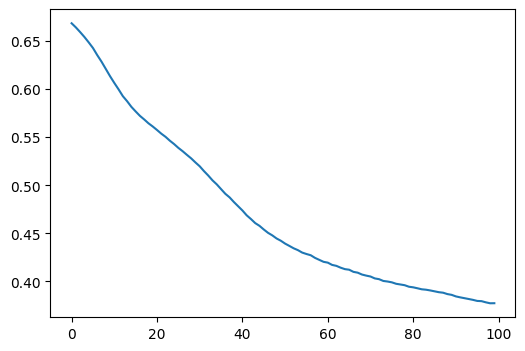

In [150]:
plt.plot(np.arange(EPOCHS), CL_trloss_synth)

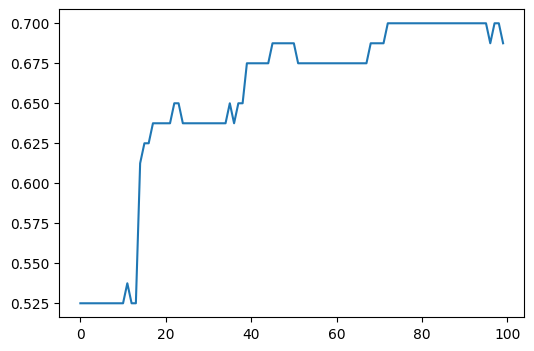

In [151]:
plt.plot(np.arange(EPOCHS), CL_val_acc_synth)

## Shouldn't oscillates that much, should take averages

# QNN
It says QNNs because we can use both sampler and estimator

In [5]:
'''
code already present above, just to have it closer
'''
# -----------------------
# Feature Map without entanglement to provide a classical map into a quantum circuit
# -----------------------
def EasyFeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    qc.barrier()
    return qc

# -----------------------
# Feature Map
# -----------------------
def FeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    for i in range(N):
        for j in range(i):
            qc.cx(j, i)
            qc.rz(x[j] * x[i], i)
            qc.cx(j, i)
        qc.barrier()
    return qc

'''
NOT CORRECT
def easy_ansatz(n_bits):
    theta = ParameterVector('theta', n_bits)
    qc = QuantumCircuit(n_bits)
    
    for i in range(n_bits):
        qc.ry(theta[i], i)
        
    return qc


def Ansatz(n_bits):
    theta = ParameterVector('theta', 2*n_bits)
    qc = QuantumCircuit(n_bits)
    for i in range(n_bits):
        qc.ry(theta[i], i)
    qc.barrier()
    for i in range(n_bits-1):
        for j in range(i+1,N):
            qc.cx(i, j)
    qc.barrier()
    for i in range(n_bits):
        qc.ry(theta[i+N], i)
    return qc
'''

# to have a QNN with 60 trainable parameters

def Ansatz_60_par(n_bits):
    theta = ParameterVector('theta', 15*n_bits)
    qc = QuantumCircuit(n_bits)

    for l in range(15):
        for i in range(n_bits):
            qc.ry(theta[i+l*n_bits], i)
        qc.barrier()
    
        for i in range(n_bits-1):
            for j in range(i+1,N):
                qc.cx(i, j)
        qc.barrier()

    return qc

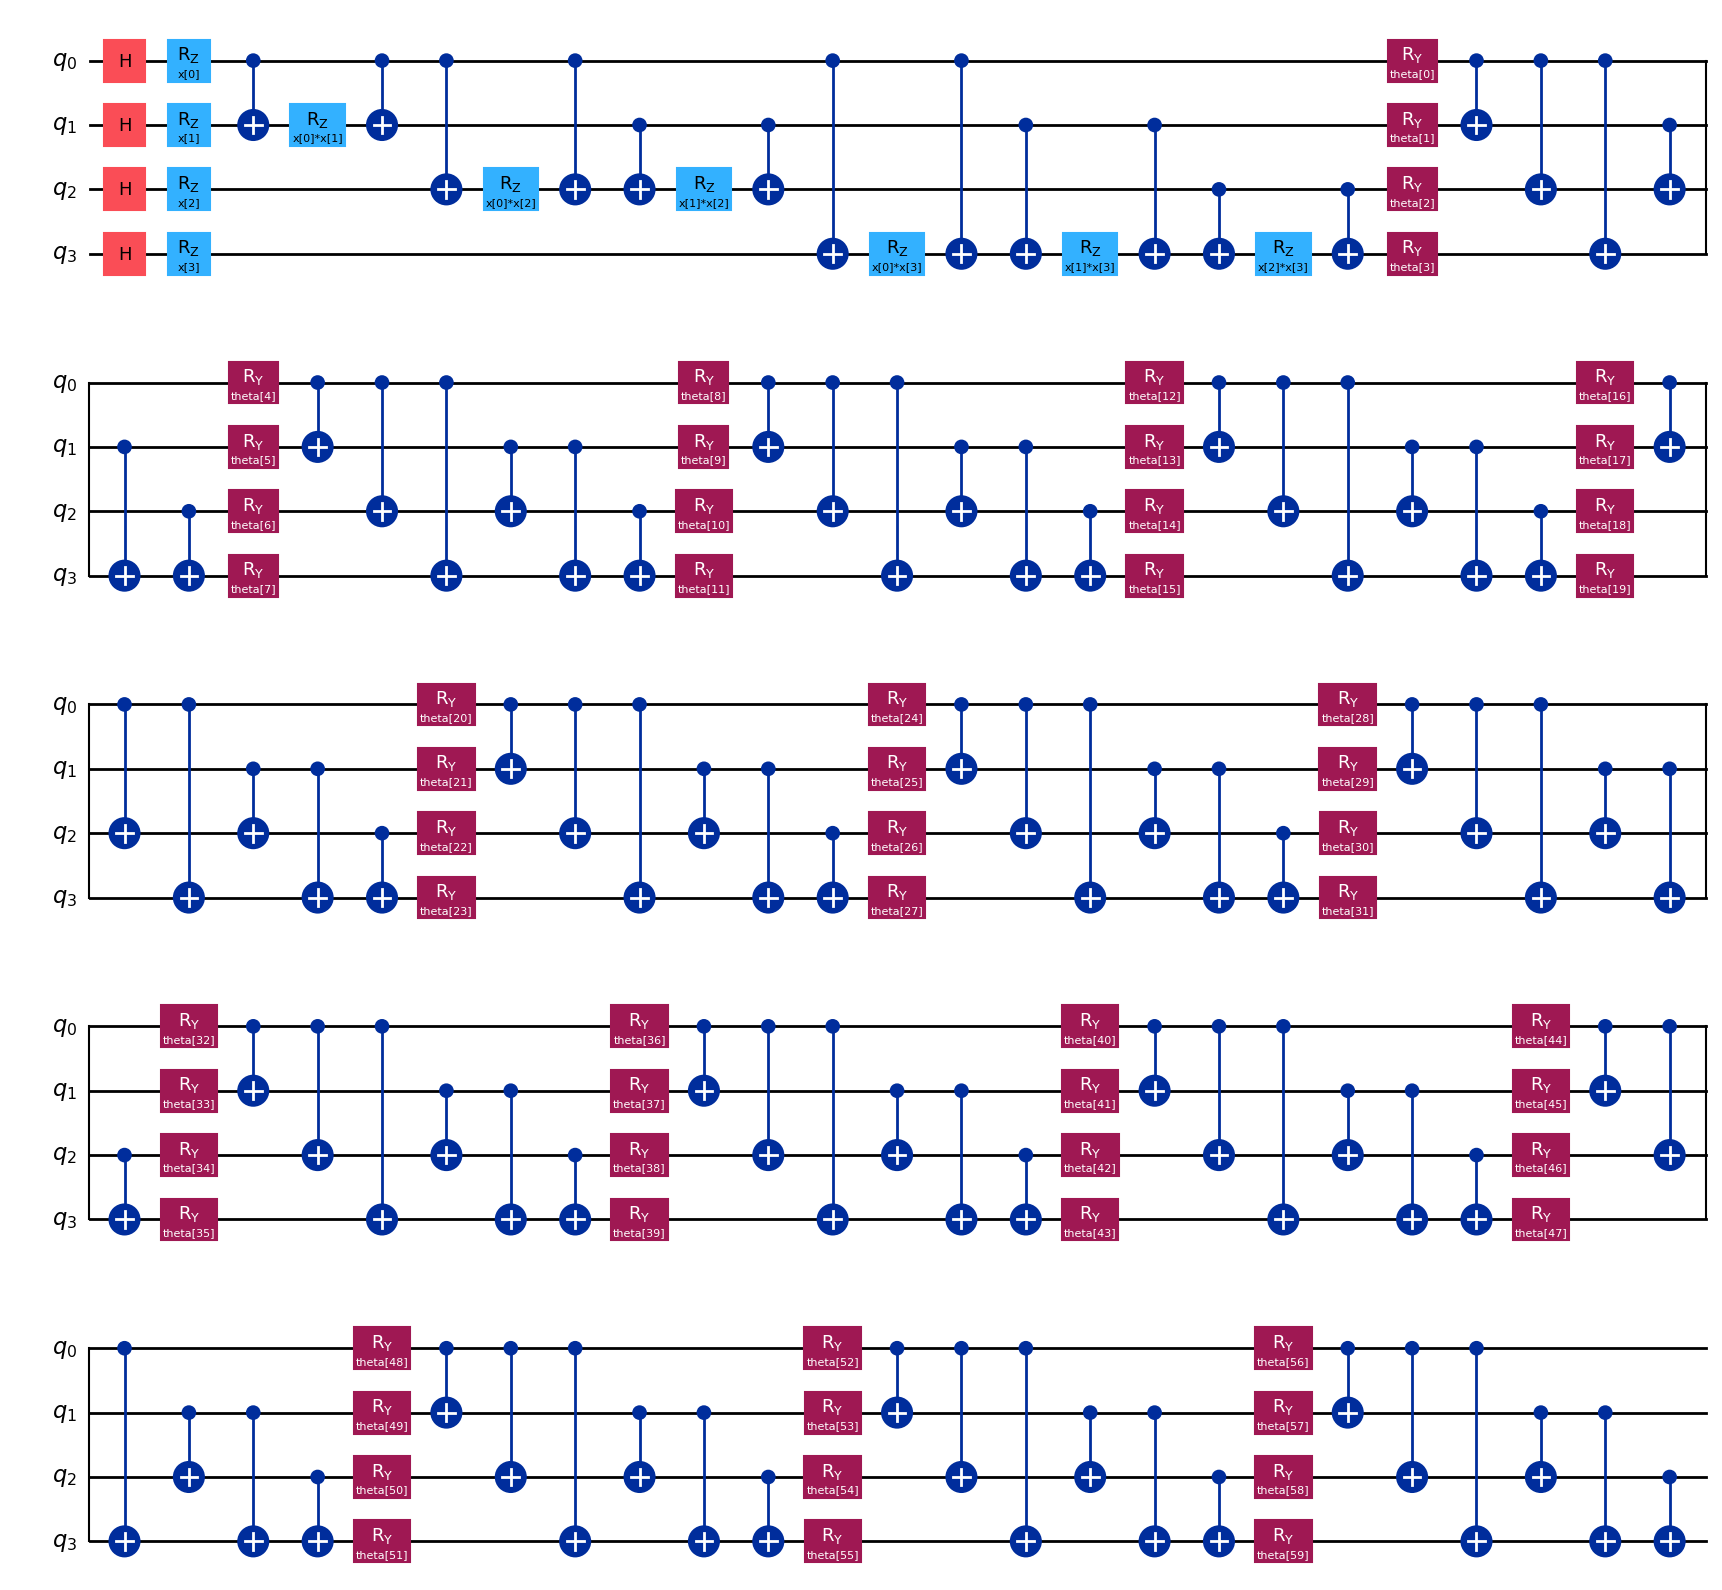

In [11]:
N = 4
# Creating the Circuits' parts
easy_feature_map = EasyFeatureMap(N)
feature_map = FeatureMap(N)
ansatz      = Ansatz_60_par(N)


qc = feature_map.copy().compose(ansatz.copy())
qc.draw("mpl", style="iqp", plot_barriers=False)

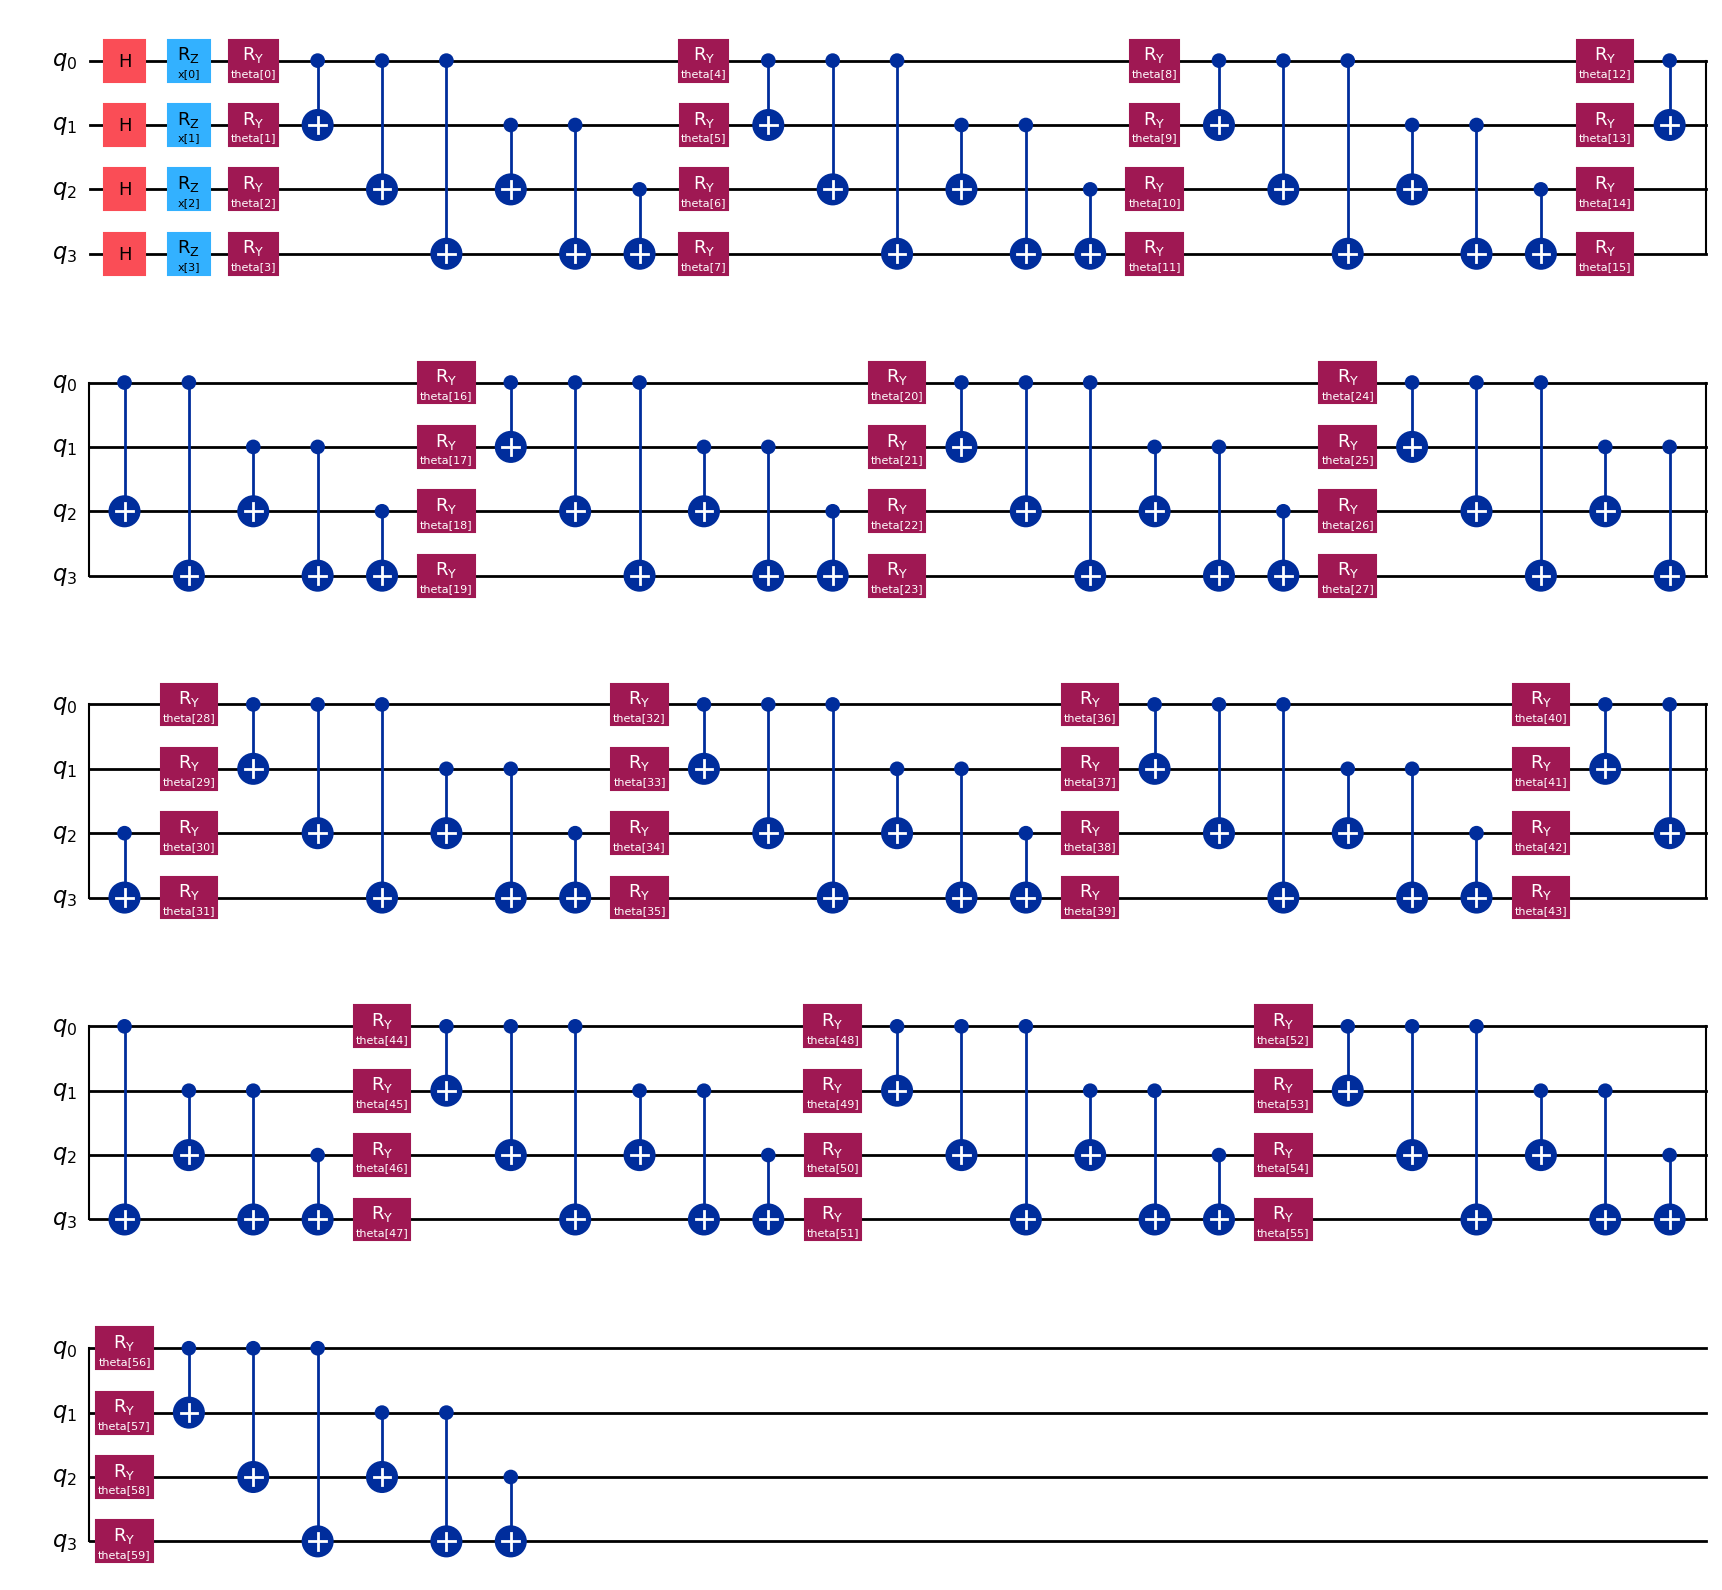

In [12]:
# easy quantum model

qc_easy = easy_feature_map.copy().compose(ansatz.copy())
qc_easy.draw("mpl", style="iqp", plot_barriers=False)

In [13]:
def make_sampler_qnn(circ):
    x_p     = sorted([p for p in circ.parameters if p.name.startswith('x')],
                      key=lambda p: p.index)
    theta_p = sorted([p for p in circ.parameters if p.name.startswith('theta')],
                      key=lambda p: p.index)
    return SamplerQNN(
        circuit=circ,
        input_params=x_p,
        weight_params=theta_p,
        interpret=parity,
        output_shape=2,
        sampler=StatevectorSampler(),
    )

qnn_s      = make_sampler_qnn(qc)
qnn_s_easy = make_sampler_qnn(qc_easy)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


In [14]:
d = qnn_s.num_weights   # number of trainable parameters = 2*N
print(f'num_weights: {d}')

d_easy = qnn_s_easy.num_weights
print(f'num_weights for easy: {d_easy}')

num_weights: 60
num_weights for easy: 60


In [41]:
# training the QNN
qnn_weights = algorithm_globals.random.random(qnn_s.num_weights)

In [40]:
print(
    f"Number of trainable weights for EstimatorQNN: {qnn_s.num_weights} \nWeights: {qnn_weights}"
)

Number of trainable weights for EstimatorQNN: 60 
Weights: [0.90436301 0.59162421 0.79015379 0.9645139  0.13309733 0.56952945
 0.11161586 0.16211461 0.68663064 0.00542785 0.03139657 0.72774675
 0.48168565 0.5406515  0.46964076 0.62326368 0.6890089  0.96970822
 0.39056071 0.57658951 0.90430928 0.03513484 0.14011221 0.98502798
 0.2852795  0.68558667 0.23643739 0.63714603 0.81531539 0.78520556
 0.87968163 0.50373405 0.91774116 0.69993537 0.22509516 0.16317904
 0.05881767 0.4139977  0.35617299 0.31127392 0.66151552 0.57119557
 0.04873418 0.8942754  0.97380857 0.24173868 0.0367467  0.1045292
 0.58024984 0.52083747 0.0978683  0.17045773 0.17406179 0.58998953
 0.14635259 0.92088449 0.52181538 0.22301526 0.27993429 0.30049562]


In [128]:
'''
# Trained weights: run a quick VQC fit to get trained parameters
def get_trained_weights(feature_map_fn, ansatz_fn, N, x_tr, y_tr, maxiter=100):
    trained_weights_store = []
    def adam_capture(fun, x0, jac=None, **kwargs):
        opt = ADAM(maxiter=maxiter, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)
        def tracked_jac(w):
            trained_weights_store.append(w.copy())
            return jac(w)
        return opt.minimize(fun=fun, x0=x0, jac=tracked_jac)
    vqc = VQC(
        sampler=StatevectorSampler(),
        feature_map=feature_map_fn(N),
        ansatz=ansatz_fn(N),
        optimizer=adam_capture,
    )
    vqc.fit(x_tr, y_tr)
    return trained_weights_store[-1] if trained_weights_store else vqc.weights

# Training QNNs for local ED
print('Training QNN for local ED...')
trained_weights_qnn  = get_trained_weights(FeatureMap,     Ansatz, N, x_train, y_train)
print('Training easy QNN for local ED...')
trained_weights_easy = get_trained_weights(EasyFeatureMap, Ansatz, N, x_train, y_train)
'''

"\n# Trained weights: run a quick VQC fit to get trained parameters\ndef get_trained_weights(feature_map_fn, ansatz_fn, N, x_tr, y_tr, maxiter=100):\n    trained_weights_store = []\n    def adam_capture(fun, x0, jac=None, **kwargs):\n        opt = ADAM(maxiter=maxiter, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)\n        def tracked_jac(w):\n            trained_weights_store.append(w.copy())\n            return jac(w)\n        return opt.minimize(fun=fun, x0=x0, jac=tracked_jac)\n    vqc = VQC(\n        sampler=StatevectorSampler(),\n        feature_map=feature_map_fn(N),\n        ansatz=ansatz_fn(N),\n        optimizer=adam_capture,\n    )\n    vqc.fit(x_tr, y_tr)\n    return trained_weights_store[-1] if trained_weights_store else vqc.weights\n\n# Training QNNs for local ED\nprint('Training QNN for local ED...')\ntrained_weights_qnn  = get_trained_weights(FeatureMap,     Ansatz, N, x_train, y_train)\nprint('Training easy QNN for local ED...')\ntrained_weights_easy = get_trained_weights

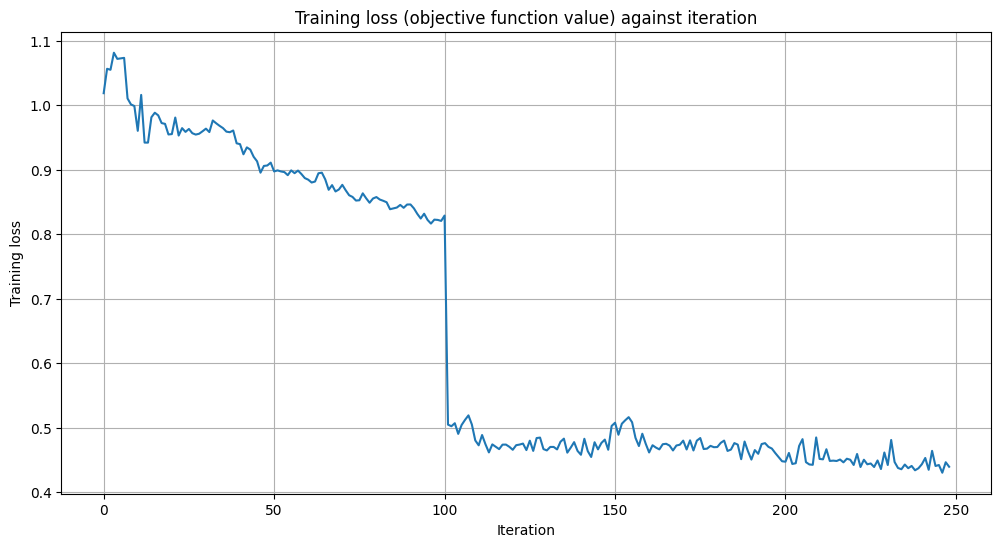

In [179]:
# just to try
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import real_amplitudes, zz_feature_map
from qiskit_machine_learning.optimizers import COBYLA, L_BFGS_B
from qiskit_machine_learning.utils import algorithm_globals

from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.circuit.library import qnn_circuit

algorithm_globals.random_seed = 42
train_acc_history = []
weights_history = []

def callback_graph(weights, obj_func_eval):
    objective_func_vals.append(obj_func_eval)
    weights_history.append(weights.copy())

qnn_classifier = NeuralNetworkClassifier(
    neural_network=qnn_s, optimizer=COBYLA(maxiter=100), callback=callback_graph
)


# fit classifier to data
qnn_classifier.fit(X_s_tr, y_s_tr)


plt.figure(figsize=(12, 6))

plt.plot(objective_func_vals)

plt.title("Training loss (objective function value) against iteration")
plt.xlabel("Iteration")
plt.ylabel("Training loss")

plt.grid(True)
plt.show()

# OBJECTIVE FUNCTION IS THE TRAINING LOSS
# SCORE is the accuracy

# ???????

In [180]:
from sklearn.metrics import accuracy_score

test_acc_history = []

for w in weights_history:
    y_pred = vqc.neural_network.forward(X_s_test, w)
    
    # convert probabilities → class labels
    y_pred_labels = np.argmax(y_pred, axis=1)

    acc = accuracy_score(y_s_test, y_pred_labels)
    test_acc_history.append(acc)

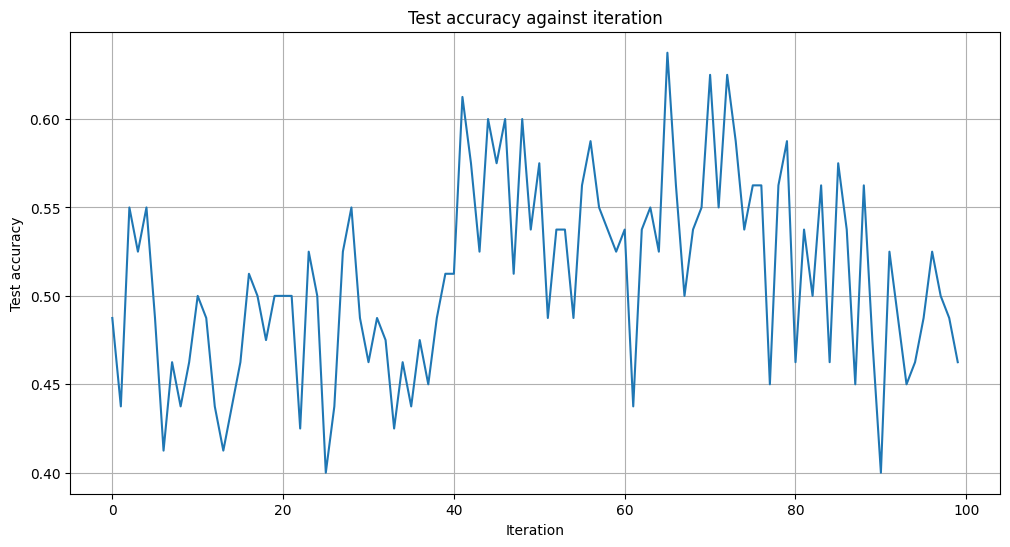

In [182]:
plt.figure(figsize=(12, 6))
plt.plot(test_acc_history)

plt.title("Test accuracy against iteration")
plt.xlabel("Iteration")
plt.ylabel("Test accuracy")

plt.grid(True)
plt.show()

The VQC is a special variant of the NeuralNetworkClassifier with a SamplerQNN. It applies a parity mapping (or extensions to multiple classes) to map from the bitstring to the classification, which results in a probability vector, which is interpreted as a one-hot encoded result. By default, it applies this the CrossEntropyLoss function that expects labels given in one-hot encoded format and will return predictions in that format too.

In [11]:
train_acc_history = []
weights_history = []

def callback_graph(nfev, x, fx, step_size, accepted):
    objective_func_vals.append(fx)
    weights_history.append(x.copy())

In [43]:
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms.optimizers import SPSA as SPSA
# construct variational quantum classifier
qc_loss      = []
qc_easy_loss = []

easy_vqc = VQC(
    feature_map=EasyFeatureMap(N),
    ansatz=Ansatz_60_par(N),
    #loss="cross_entropy",
    optimizer=make_adam_tracker(qc_easy_loss),
    callback=callback_graph,
    sampler=StatevectorSampler(),
)

vqc = VQC(
    feature_map=FeatureMap(N),
    ansatz=Ansatz_60_par(N),
    #loss="cross_entropy",
    optimizer=make_adam_tracker(qc_loss),
    callback=callback_graph,
    sampler=StatevectorSampler(),
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


In [ ]:
# create empty array for callback to store evaluations of the objective function
# y_s_tr_oh = np.eye(2)[y_s_tr]
# y_s_test_oh = np.eye(2)[y_s_test]

# fit classifier to data
vqc.fit(x_train, y_train)

In [172]:
from sklearn.metrics import accuracy_score

test_acc_history = []

for w in weights_history:
    y_pred = vqc.neural_network.forward(X_s_test, w)
    
    # convert probabilities → class labels
    y_pred_labels = np.argmax(y_pred, axis=1)

    acc = accuracy_score(y_s_test, y_pred_labels)
    test_acc_history.append(acc)

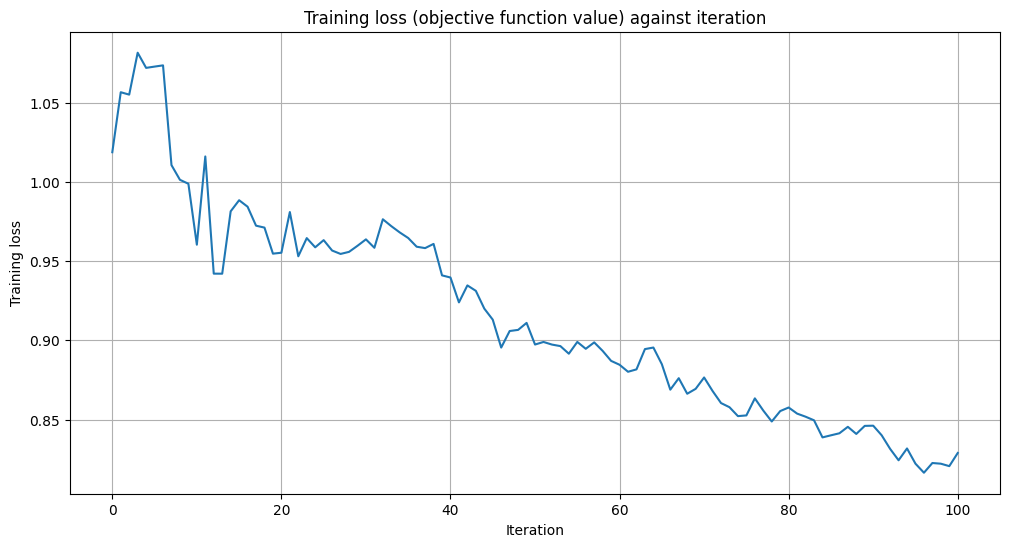

In [173]:
plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)

plt.title("Training loss (objective function value) against iteration")
plt.xlabel("Iteration")
plt.ylabel("Training loss")

plt.grid(True)
plt.show()

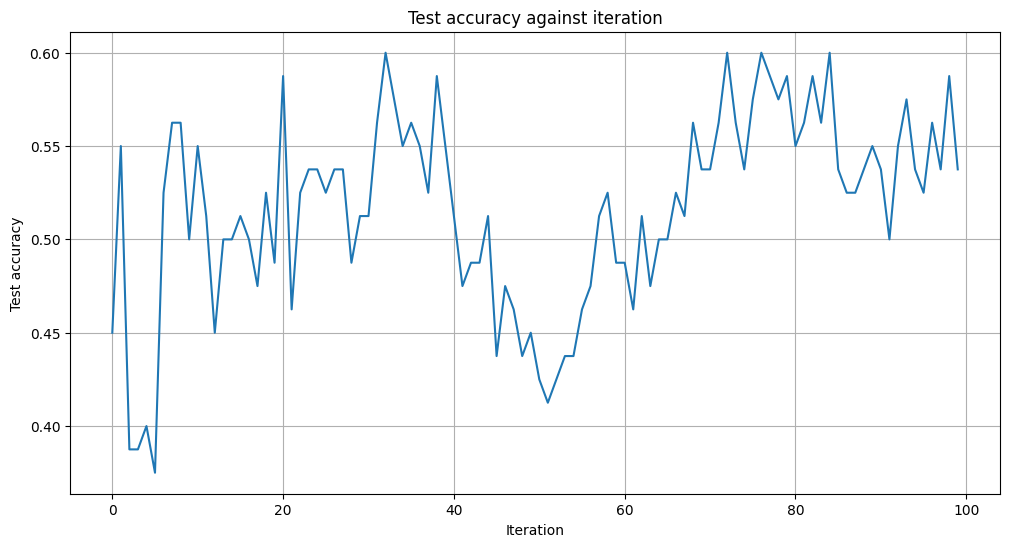

In [176]:
plt.figure(figsize=(12, 6))
plt.plot(test_acc_history)

plt.title("Test accuracy against iteration")
plt.xlabel("Iteration")
plt.ylabel("Test accuracy")

plt.grid(True)
plt.show()

# Test with ADAM

In [ ]:
N_TRIALS = 5
MAX_ITER = 100

# Storico per entrambi i modelli
all_losses_qc      = []   # (N_TRIALS, n_iter)
all_losses_easy    = []   # (N_TRIALS, n_iter)
all_train_acc_qc   = []
all_test_acc_qc    = []
all_train_acc_easy = []
all_test_acc_easy  = []

def make_adam_tracker(loss_list, maxiter=100, N=4):
    log_n = np.log2(N)

    def adam_with_tracking(fun, x0, jac=None, **kwargs):
        optimizer = ADAM(maxiter=maxiter, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)

        _cache = {'weights': None, 'loss': None}

        def cached_fun(weights):
            if _cache['weights'] is None or not np.array_equal(weights, _cache['weights']):
                _cache['weights'] = weights.copy()
                _cache['loss']    = fun(weights)
            return _cache['loss']

        def tracked_jac(weights):
            loss = cached_fun(weights)               
            loss_list.append(float(loss) / log_n)
            return jac(weights)

        return optimizer.minimize(fun=cached_fun, x0=x0, jac=tracked_jac)
    return adam_with_tracking
    
import gc
import os
import pickle

for trial in range(N_TRIALS):
    print(f'\n── Trial {trial+1:>3d}/{N_TRIALS} ──')

    trial_loss_qc   = []
    trial_loss_easy = []

    # ── QNN ──
    trial_vqc = VQC(
        sampler=StatevectorSampler(),
        feature_map=FeatureMap(N),
        ansatz=Ansatz_60_par(N),
        optimizer=make_adam_tracker(trial_loss_qc, MAX_ITER, N),
    )
    trial_vqc.fit(x_train, y_train)
    train_acc_qc = trial_vqc.score(x_train, y_train)
    test_acc_qc  = trial_vqc.score(x_test,  y_test)
    print(f'  QNN -> train: {train_acc_qc:.2%} | test: {test_acc_qc:.2%}')

    # Salva subito e libera
    os.makedirs("TRIAL", exist_ok=True)
    with open(f"TRIAL/loss_qnn_{trial}.pkl",  "wb") as f: pickle.dump(trial_loss_qc,  f)
    with open(f"TRIAL/train_qnn_{trial}.pkl", "wb") as f: pickle.dump(train_acc_qc,   f)
    with open(f"TRIAL/test_qnn_{trial}.pkl",  "wb") as f: pickle.dump(test_acc_qc,    f)

    del trial_vqc, trial_loss_qc   # ← libera esplicitamente
    gc.collect()                   # ← forza il garbage collector

    # ── easy QNN ──
    trial_vqc_easy = VQC(
        sampler=StatevectorSampler(),
        feature_map=EasyFeatureMap(N),
        ansatz=Ansatz_60_par(N),
        optimizer=make_adam_tracker(trial_loss_easy, MAX_ITER, N),
    )
    trial_vqc_easy.fit(x_train, y_train)
    train_acc_easy = trial_vqc_easy.score(x_train, y_train)
    test_acc_easy  = trial_vqc_easy.score(x_test,  y_test)
    print(f'  easy -> train: {train_acc_easy:.2%} | test: {test_acc_easy:.2%}')

    with open(f"TRIAL/loss_easy_{trial}.pkl",  "wb") as f: pickle.dump(trial_loss_easy,  f)
    with open(f"TRIAL/train_easy_{trial}.pkl", "wb") as f: pickle.dump(train_acc_easy,   f)
    with open(f"TRIAL/test_easy_{trial}.pkl",  "wb") as f: pickle.dump(test_acc_easy,    f)

    del trial_vqc_easy, trial_loss_easy
    gc.collect()

    # Accumula solo i valori scalari — non i circuiti
    all_losses_qc.append(f"TRIAL/loss_qnn_{trial}.pkl")  
    all_train_acc_qc.append(train_acc_qc)
    all_test_acc_qc.append(test_acc_qc)
    all_losses_easy.append(f"TRIAL/loss_easy_{trial}.pkl")
    all_train_acc_easy.append(train_acc_easy)
    all_test_acc_easy.append(test_acc_easy)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.



── Trial   1/5 ──


In [ ]:
# Ricarica le loss dai file quando servono per il plot
all_losses_qc_data   = []
all_losses_easy_data = []

for trial in range(N_TRIALS):
    with open(f"TRIAL/loss_qnn_{trial}.pkl",  "rb") as f:
        all_losses_qc_data.append(pickle.load(f))
    with open(f"TRIAL/loss_easy_{trial}.pkl", "rb") as f:
        all_losses_easy_data.append(pickle.load(f))

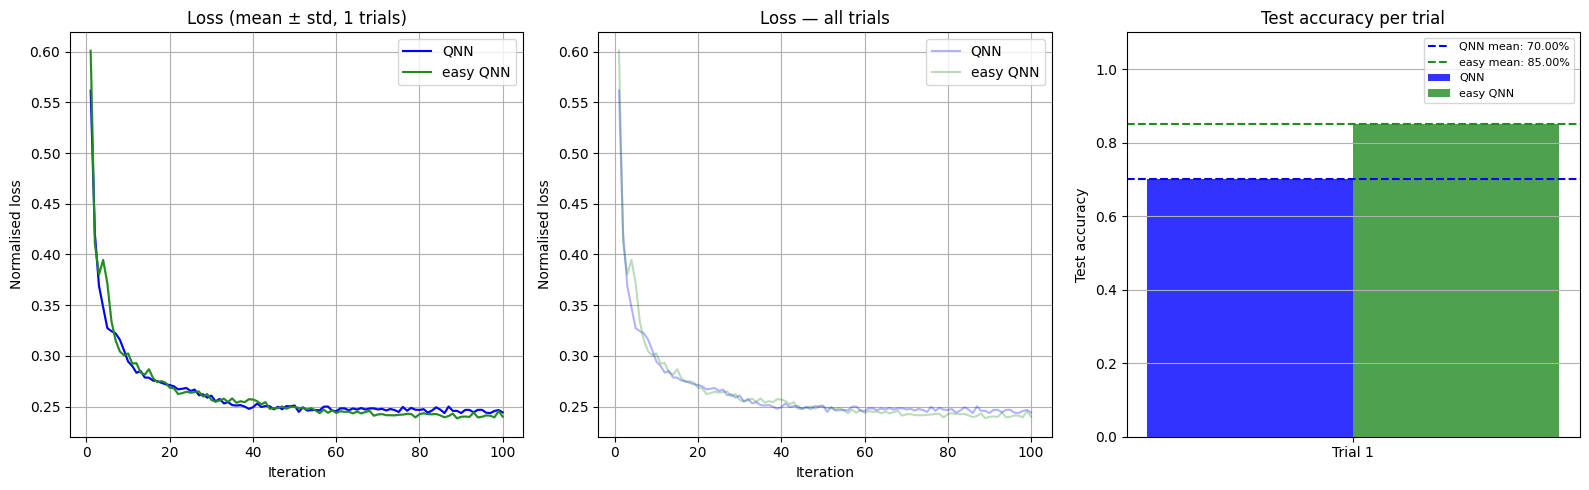

                        Train acc     Test acc
----------------------------------------------
QNN mean                   98.75%       70.00%
QNN std                     0.00%        0.00%
easy QNN mean              85.00%       85.00%
easy QNN std                0.00%        0.00%


In [15]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

N_TRIALS = 5   # adatta al tuo numero di trial

# ── Carica tutti i pickle ─────────────────────────────────────
all_losses_qc_data   = []
all_losses_easy_data = []
all_train_acc_qc     = []
all_train_acc_easy   = []
all_test_acc_qc      = []
all_test_acc_easy    = []

for trial in range(N_TRIALS):
    with open(f"TRIAL/loss_qnn_{trial}.pkl",   "rb") as f: all_losses_qc_data.append(pickle.load(f))
    with open(f"TRIAL/loss_easy_{trial}.pkl",  "rb") as f: all_losses_easy_data.append(pickle.load(f))
    with open(f"TRIAL/train_qnn_{trial}.pkl",  "rb") as f: all_train_acc_qc.append(pickle.load(f))
    with open(f"TRIAL/train_easy_{trial}.pkl", "rb") as f: all_train_acc_easy.append(pickle.load(f))
    with open(f"TRIAL/test_qnn_{trial}.pkl",   "rb") as f: all_test_acc_qc.append(pickle.load(f))
    with open(f"TRIAL/test_easy_{trial}.pkl",  "rb") as f: all_test_acc_easy.append(pickle.load(f))

# ── Statistiche loss ──────────────────────────────────────────
min_iter      = min(min(len(l) for l in all_losses_qc_data),
                    min(len(l) for l in all_losses_easy_data))
loss_arr_qc   = np.array([l[:min_iter] for l in all_losses_qc_data])   # (N_TRIALS, min_iter)
loss_arr_easy = np.array([l[:min_iter] for l in all_losses_easy_data])
iters         = np.arange(1, min_iter + 1)

loss_mean_qc   = loss_arr_qc.mean(axis=0)
loss_std_qc    = loss_arr_qc.std(axis=0)
loss_mean_easy = loss_arr_easy.mean(axis=0)
loss_std_easy  = loss_arr_easy.std(axis=0)

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 1. Loss media ± std ───────────────────────────────────────
axes[0].plot(iters, loss_mean_qc,   color='blue',        label='QNN')
axes[0].fill_between(iters,
    loss_mean_qc  - loss_std_qc,
    loss_mean_qc  + loss_std_qc,
    alpha=0.2, color='blue')
axes[0].plot(iters, loss_mean_easy, color='forestgreen', label='easy QNN')
axes[0].fill_between(iters,
    loss_mean_easy - loss_std_easy,
    loss_mean_easy + loss_std_easy,
    alpha=0.2, color='forestgreen')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Normalised loss')
axes[0].set_title(f'Loss (mean ± std, {N_TRIALS} trials)')
axes[0].legend()
axes[0].grid(True)

# ── 2. Loss per singolo trial (tutte le curve) ────────────────
for i, l in enumerate(all_losses_qc_data):
    axes[1].plot(range(1, len(l)+1), l,
                 color='blue', alpha=0.3,
                 label='QNN' if i == 0 else '')
for i, l in enumerate(all_losses_easy_data):
    axes[1].plot(range(1, len(l)+1), l,
                 color='forestgreen', alpha=0.3,
                 label='easy QNN' if i == 0 else '')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Normalised loss')
axes[1].set_title('Loss — all trials')
axes[1].legend()
axes[1].grid(True)

# ── 3. Test accuracy per trial ────────────────────────────────
x_pos = np.arange(N_TRIALS)
width = 0.35
axes[2].bar(x_pos - width/2, all_test_acc_qc,   width,
            color='blue',        alpha=0.8, label='QNN')
axes[2].bar(x_pos + width/2, all_test_acc_easy, width,
            color='forestgreen', alpha=0.8, label='easy QNN')
axes[2].axhline(np.mean(all_test_acc_qc),
                color='blue',        linestyle='--', linewidth=1.5,
                label=f'QNN mean: {np.mean(all_test_acc_qc):.2%}')
axes[2].axhline(np.mean(all_test_acc_easy),
                color='forestgreen', linestyle='--', linewidth=1.5,
                label=f'easy mean: {np.mean(all_test_acc_easy):.2%}')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([f'Trial {i+1}' for i in range(N_TRIALS)])
axes[2].set_ylabel('Test accuracy')
axes[2].set_ylim([0, 1.1])
axes[2].set_title('Test accuracy per trial')
axes[2].legend(fontsize=8)
axes[2].grid(True, axis='y')

plt.tight_layout()
plt.show()

# ── Stampa riepilogo ──────────────────────────────────────────
print(f"{'':20} {'Train acc':>12} {'Test acc':>12}")
print("-" * 46)
print(f"{'QNN mean':20} {np.mean(all_train_acc_qc):>12.2%} {np.mean(all_test_acc_qc):>12.2%}")
print(f"{'QNN std':20} {np.std(all_train_acc_qc):>12.2%} {np.std(all_test_acc_qc):>12.2%}")
print(f"{'easy QNN mean':20} {np.mean(all_train_acc_easy):>12.2%} {np.mean(all_test_acc_easy):>12.2%}")
print(f"{'easy QNN std':20} {np.std(all_train_acc_easy):>12.2%} {np.std(all_test_acc_easy):>12.2%}")

Unsurprisingly, the classical models perform better than their quantum counterparts, but classical ML has come a long way, and quantum ML has yet to reach that level of maturity.

# Classical NN vs QNN (our Point Of View)
## Neural Networks are self learning features Map + machine Learning 
What NN do is the following:
* *Learning a Feature Map* this task is performed by all the layers except the last one
* *Classification/Regression Task* performed just by the last layer
The reason why NN are so efficient arises exactly from what we just stades: by learning an effective and complex feature map, the NN can capture some higher-abstraction features. Higher-abstraction features are combination of lower-level features which are recursively (meaning that each fature is a combination of lower level features) obtained from the input.
## Experiment
In the following we'll give the same fature map: 

$\phi(x) = \{1, x, x^2, x^3, x^4\}$

and we'll perform a regression on a simple dataset (polinomyal function with Gaussian Noise). 
Then we'll compute the FisherInformation and the Effective dimension for both the Networks. 
Doing this we'll estimate which of the two has the best Power.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input

### Dataset Definition
We defined polinomial true hypothesis with random coefficent (we set the random seed for reproducibility).
A Gausian noise is added to the data

In [12]:
# dataset definition
np.random.seed(123456789)
true_params = np.random.rand(4)*5
N = 100
x = np.linspace(-1, 1, N)
y = true_params[0] + x*true_params[1] + x**2*true_params[2] + x**3*true_params[3]
#adding noise
for i in range(N):
    y[i] +=  np.random.normal(loc=0.0, scale=(true_params[0] + x[-1]*true_params[1] + x[-1]**2*true_params[2] + x[-1]**3*true_params[3])*0.05)

idx = np.arange(len(x))
np.random.shuffle(idx)

x_training = x[idx[:int(len(x)*0.8)]]
y_training = y[idx[:int(len(x)*0.8)]] 

x_test = x[idx[int(len(x)*0.8):]]
y_test = y[idx[int(len(x)*0.8):]]

# feature map
def feature_map(x):
    return np.column_stack([np.ones_like(x), x, x**2, x**3, x**4])


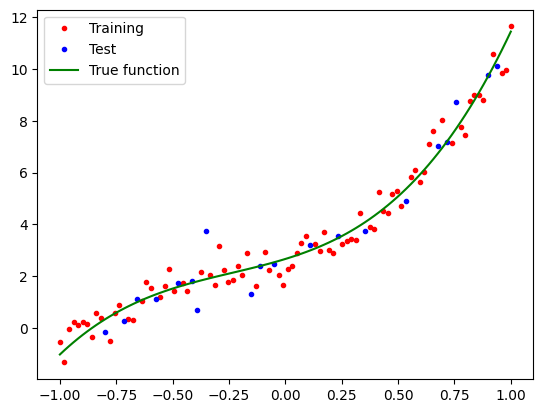

In [13]:
plt.plot(x_training, y_training, "r.", label="Training")
plt.plot(x_test, y_test, "b.", label="Test")
y_true = true_params[0] + x*true_params[1] + x**2*true_params[2] + x**3*true_params[3]
plt.plot(x, y_true, "g-", label="True function")
plt.legend()

### Classical NN model definition

We define the model as following:
* _Input_ (dimension 1)
* _First Layer_ Dense, 5 neurons, no bias
* _Second Layer_ Dense, 1 neuron, no bias

Total number of trainable weights: $5 * 5 + 5 * 1 = 30$

In [25]:
#model definition
model = Sequential()

model.add(Dense(5, kernel_initializer='he_normal', use_bias=False, input_shape=(5,)))
model.add(Dense(1, kernel_initializer='he_normal', use_bias=False))

model.compile(optimizer='adam',
              loss='mse',
              metrics=['accuracy'])

EPOCHS = 400
BATCH_SIZE = 10

fm_training = feature_map(x_training)
fm_test = feature_map(x_test)

fit = model.fit(fm_training, y_training,
                batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(fm_test, y_test),
                verbose=False,
                shuffle=True)

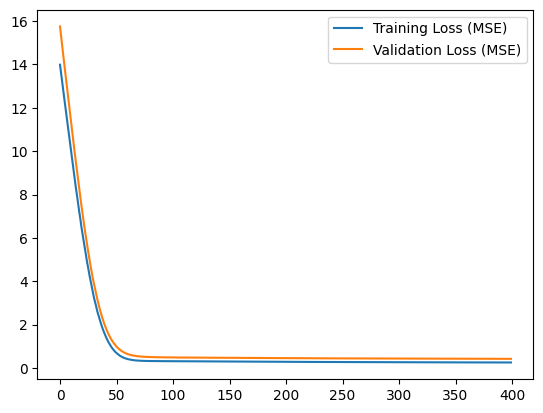

In [26]:
plt.plot(fit.history['loss'], label='Training Loss (MSE)')
plt.plot(fit.history['val_loss'], label='Validation Loss (MSE)')
plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


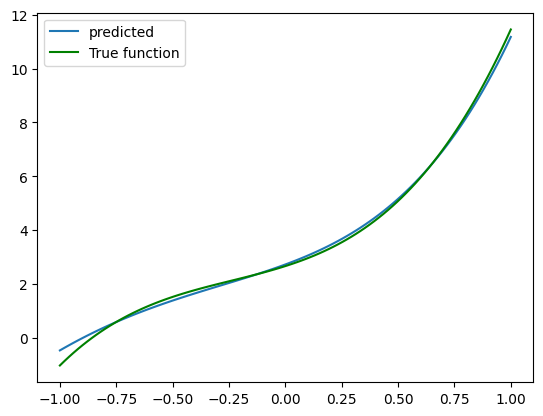

In [27]:
y_pred = model.predict(feature_map(x))
plt.plot(x, y_pred, label="predicted")
plt.plot(x, y_true, "g-", label="True function")
plt.legend()
mse = np.mean((y_test - y_pred) ** 2)

### Quantum Model Definition


In [36]:
def normalize_y(y):
    return 2 * (y - y_min) / (y_max - y_min) - 1

def denormalize_y(y_norm):
    return (y_norm + 1)  * (y_max - y_min)/2 + y_min

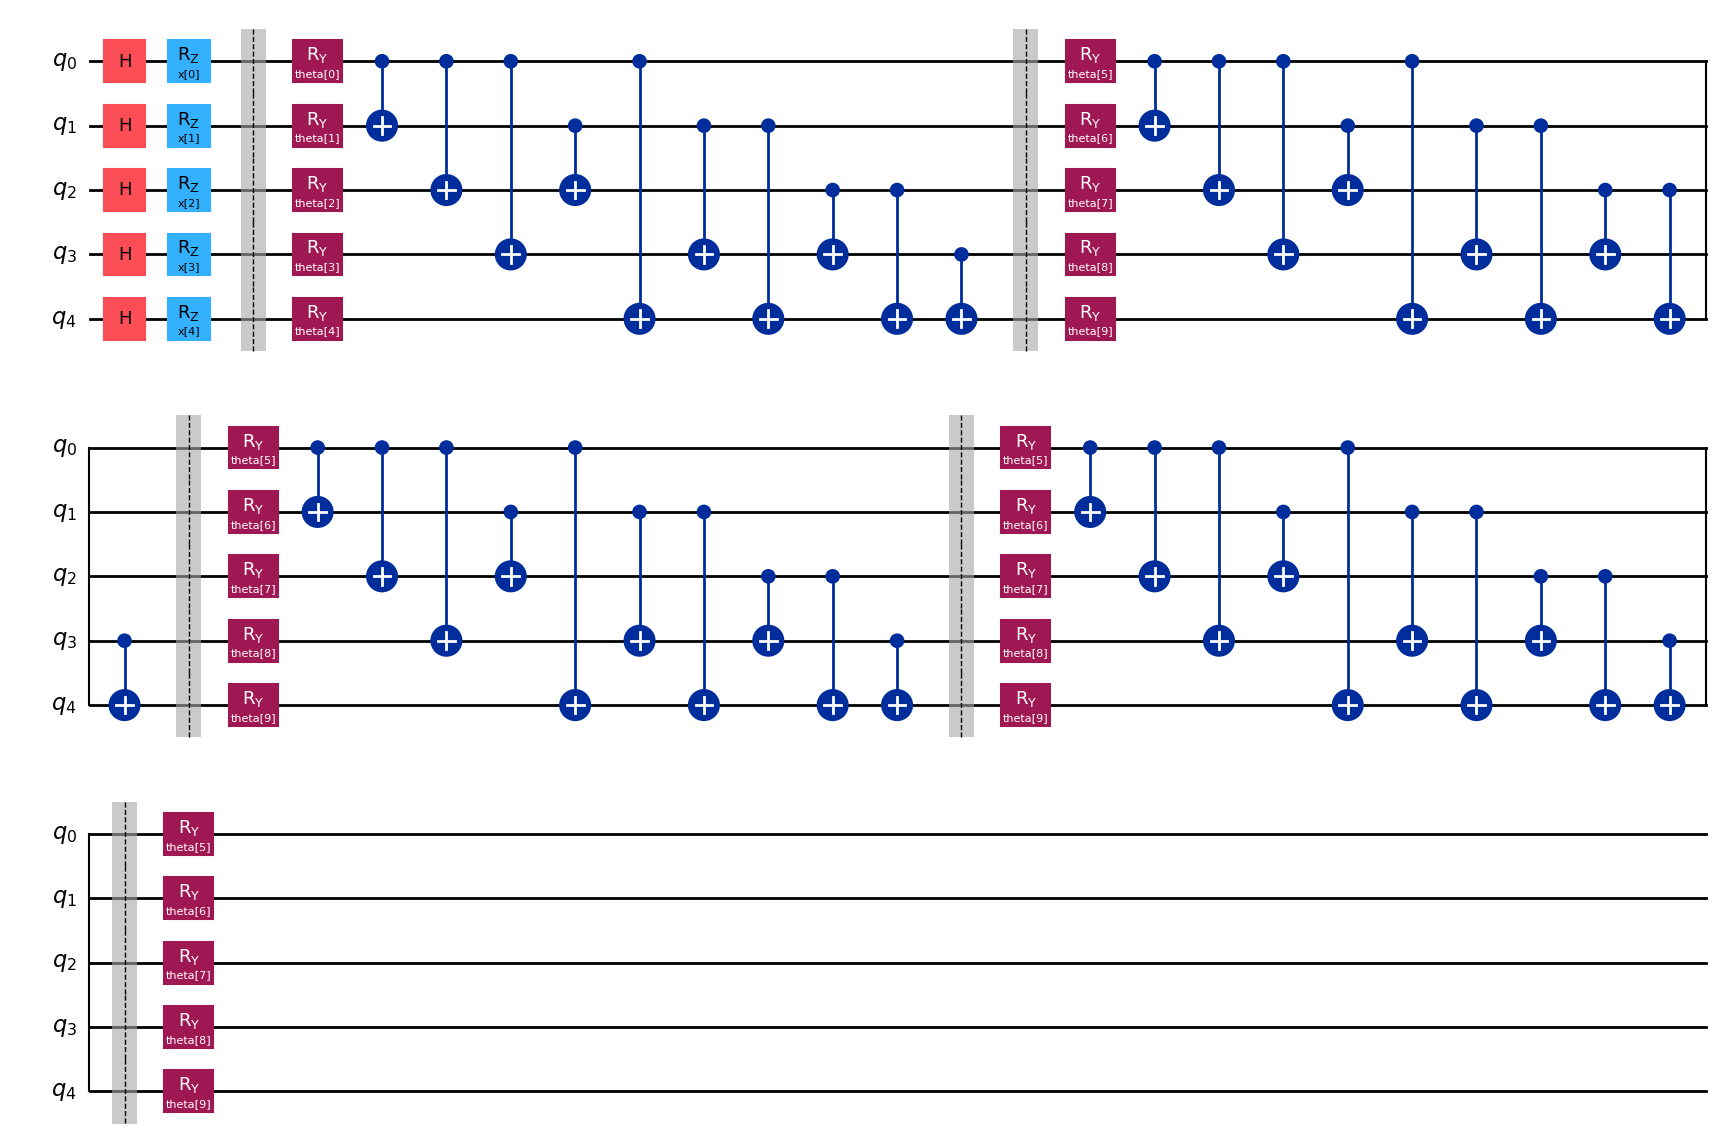

In [37]:
def qnn_ansatz(N):
    theta = ParameterVector('theta', 2*N)
    qc = QuantumCircuit(N)
    for i in range(N):
        qc.ry(theta[i], i)
    
    for _ in range(4):
        for i in range(N-1):
            for j in range(i+1,N):
                qc.cx(i, j)
        qc.barrier()
        for i in range(N):
            qc.ry(theta[i+N], i)
    return qc


circuit =  QNN_builder(5, EasyFeatureMap, qnn_ansatz, depth=1)
circuit.draw("mpl")

In [49]:
#reference for the circuit
#https://medium.com/@anirudhsekar2008/quantum-regression-in-action-building-a-variational-quantum-regressor-with-qiskit-38ddbceab482
from qiskit_algorithms.optimizers import SPSA
from qiskit_machine_learning.algorithms.regressors import VQR
from qiskit.primitives import StatevectorEstimator
estimator = StatevectorEstimator()


loss_history = []

EPOCH = 1000
def setup_quantum_regression(feature_map, ansatz):
    global loss_history
    loss_history = []
    
   
    def callback_function(nfev, x_next, fx_next, update_step, accepted):
        
        loss_history.append(fx_next)
        
        # Stampiamo l'avanzamento ogni 5 o 10 iterazioni per non intasare l'output
        if nfev % 10 == 0:
            print(f"Step {nfev}  Loss: {fx_next:.4f}")

    # Configura l'ottimizzatore SPSA
    optimizer = SPSA(maxiter=EPOCHS, learning_rate=0.05, perturbation=0.01)
    estimator = StatevectorEstimator()

    #VQR stands for cariational quantum regressor
    vqr = VQR(
        estimator=estimator,
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        callback=callback_function
    )
    
    return vqr

fm = EasyFeatureMap(5)
ansatz = qnn_ansatz(5)
vqr = setup_quantum_regression(fm, ansatz)

#this is needed since the input shuold be normalized for being properly encoded in the Qubit
#The output has to be denormalized since it is normalized as well

scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
fm_training_scaled = scaler.fit_transform(fm_training)
fm_test_scaled = scaler.transform(fm_test)

y_min, y_max = y_training.min(), y_training.max()

y_training_norm = normalize_y(y_training)
y_test_norm = normalize_y(y_test)

#training
vqr.fit(fm_training, y_training_norm)

#prediction and test
y_pred_norm = vqr.predict(fm_test)
y_pred = denormalize_y(y_pred_norm) 
mse = np.mean((y_test - y_pred) ** 2)

print(mse)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Step 30  Loss: 0.2321
Step 60  Loss: 0.1796
Step 90  Loss: 0.1549
Step 120  Loss: 0.1421
Step 150  Loss: 0.1364
Step 180  Loss: 0.1297
Step 210  Loss: 0.1267
Step 240  Loss: 0.1201
Step 270  Loss: 0.1170
Step 300  Loss: 0.1150
Step 330  Loss: 0.1134
Step 360  Loss: 0.1133
Step 390  Loss: 0.1134
Step 420  Loss: 0.1113
Step 450  Loss: 0.1107
Step 480  Loss: 0.1121
Step 510  Loss: 0.1064
Step 540  Loss: 0.1052
Step 570  Loss: 0.1067
Step 600  Loss: 0.1053
Step 630  Loss: 0.1050
Step 660  Loss: 0.1011
Step 690  Loss: 0.1031
Step 720  Loss: 0.1015
Step 750  Loss: 0.1000
Step 780  Loss: 0.0959
Step 810  Loss: 0.0976
Step 840  Loss: 0.0970
Step 870  Loss: 0.0945
Step 900  Loss: 0.0938
Step 930  Loss: 0.0929
Step 960  Loss: 0.0954
Step 990  Loss: 0.0919
Step 1020  Loss: 0.0912
Step 1050  Loss: 0.0916
Step 1080  Loss: 0.0897
Step 1110  Loss: 0.0875
Step 1140  Loss: 0.0896
Step 1170  Loss: 0.0867
Step 1200  Loss: 0.0875
10.8992097590008


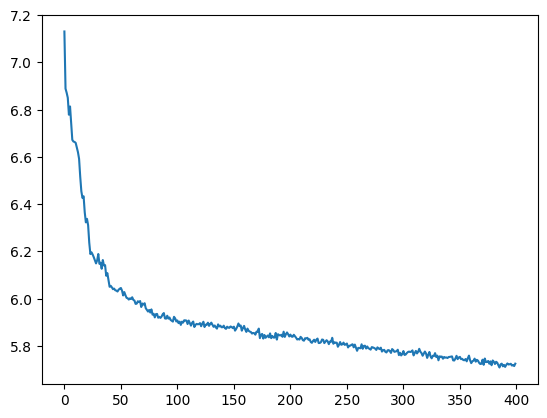

In [50]:
plt.plot(denormalize_y(np.array(loss_history)))  
#plt.plot(fit.history['loss'], label='Training Loss (MSE)')

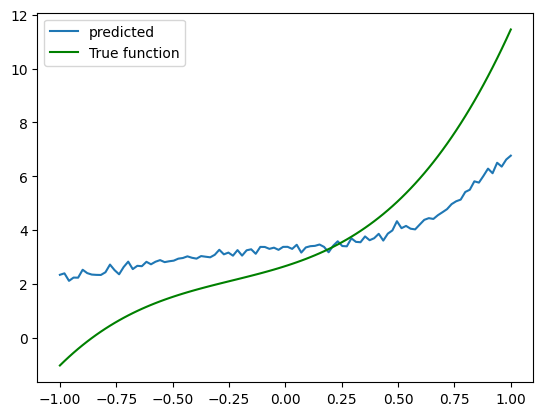

In [51]:
y_pred_norm = vqr.predict(feature_map(x))
y_pred = denormalize_y(y_pred_norm) 
plt.plot(x, y_pred, label="predicted")
plt.plot(x, y_true, "g-", label="True function")
plt.legend()